# User analysis for all (non-categorized users) 

In [32]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import powerlaw, truncnorm
import powerlaw
from scipy import stats

In [33]:
# import datasets
df = pd.read_json("../../Datasets/voluntariosdanavalencia_old.json") # Import data from Voluntarios de Valencia groupchat.


In [34]:
df.head()

,id,date,message,reply_to_msg_id,views,forwards,edit_date,pinned,post_author,sender_id,sender_username,sender_name,has_media,reactions,subgroup,topic_name,reply
0,3,2024-10-30 12:39:24+00:00,Os paso por aquí el correo,NaN,NaN,NaN,None,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,False,[],None,Discusión general,False
1,4,2024-10-30 12:40:50+00:00,LO AVISÉ EL VIERNES PASADO Y NADIE ME HIZO CAS...,NaN,46823.0,1057.0,2024-11-01T18:21:38+00:00,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,True,"[{'user_id': 5887977931, 'username': '', 'disp...",None,Discusión general,False
2,5,2024-10-30 12:43:17+00:00,,NaN,NaN,NaN,2024-11-03T22:44:05+00:00,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,True,"[{'user_id': 6970134793, 'username': '', 'disp...",None,Discusión general,False
3,6,2024-10-30 12:43:23+00:00,Probad si podeis,NaN,NaN,NaN,None,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,False,[],None,Discusión general,False
4,7,2024-10-30 12:46:02+00:00,Durante la tormenta al parecer sí estaba opera...,4.0,NaN,NaN,None,False,NaN,941865373,Camelocota,Víctor Conejero,False,[],Thread_4,Discusión general,True


In [35]:
#Uncomment to see only messages from 2024. 
#date_tz = df['date'].dt.tz
#cutoff_date = pd.Timestamp('2025-01-01', tz=date_tz) if date_tz is not None else pd.Timestamp('2025-01-01')
#df = df[df['date'] < cutoff_date].copy()


In [36]:
def normalize_data(df):
    df["id"]= pd.to_numeric(df["id"], errors='coerce').astype('Int64')   # Convert 'id' to numeric, coercing errors to NaN.
    df["sender_id"]= pd.to_numeric(df["sender_id"], errors='coerce').astype('Int64')   # Convert 'sender_id' to numeric, coercing errors to NaN.
    df["date"]= pd.to_datetime(df["date"], errors='coerce')   # Convert 'date' to datetime, coercing errors to NaT.
    df["edit_date"]= pd.to_datetime(df["edit_date"], errors='coerce')   # Convert 'edit_date' to datetime, coercing errors to NaT.
    df["reply_to_msg_id"]= pd.to_numeric(df["reply_to_msg_id"], errors='coerce').astype('Int64')   # Convert 'reply_to_message_id' to numeric, coercing errors to NaN.
    df["views"]= pd.to_numeric(df["views"], errors='coerce').astype('Int64')   # Convert 'views' to numeric, coercing errors to NaN.
    df["forwards"]= pd.to_numeric(df["forwards"], errors='coerce').astype('Int64')   # Convert 'forwards' to numeric, coercing errors to NaN.
    return df
df = normalize_data(df) # Normalize the data types of the DataFrame columns.


In [37]:
# Gather users with 100 or more messages sent 
active_users = df['sender_id'].value_counts()[df['sender_id'].value_counts() >= 100].index.tolist() # Gather sender IDs of users with 50 or more messages sent.
len(active_users)

26

In [38]:
active_users_messages = df[df['sender_id'].isin(active_users)] # Filter the DataFrame to include only messages from active users.


In [39]:
def filter_users_by_activity(active_users, messages_df, min_days=5):
    kept_users = []
    min_period = pd.Timedelta(days=min_days)
    for user in active_users:
        user_messages = messages_df[messages_df['sender_id'] == user] # Gather messages sent by the user.
        user_dates = pd.to_datetime(user_messages['date'], errors='coerce').dropna()
        if user_dates.empty:
            continue
        period_of_activity = user_dates.max() - user_dates.min() # Calculate the period of activity of the user.
        if period_of_activity >= min_period:
            kept_users.append(user)
    return kept_users

active_users = filter_users_by_activity(active_users, df, min_days=5) # Filter active users by a minimum period of activity of 5 days.
len(active_users)

25

## Waiting times

In [40]:
# Plain power-law fit function for waiting times, with comparisons to other distributions and KS test on the tail


def fit_power_law_report(waiting_times_input, label, discrete=True, show_results=True, show_plots=True):
    data_pl = np.asarray(waiting_times_input, dtype=float)
    data_pl = data_pl[np.isfinite(data_pl)]
    data_pl = data_pl[data_pl > 0]

    if len(data_pl) < 20:
        if show_results:
            print("=" * 70)
            print(f"{label}: Not enough data to fit reliably (n={len(data_pl)}).")
            print("=" * 70)
        return None

    fit_pl = powerlaw.Fit(data_pl, discrete=discrete, verbose=False)
    pl = fit_pl.power_law

    alpha_pl = getattr(pl, "alpha", np.nan)
    xmin_pl = getattr(pl, "xmin", np.nan)
    sigma_pl = getattr(pl, "sigma", np.nan)

    tail_pl = np.sort(data_pl[data_pl >= xmin_pl])
    if len(tail_pl) == 0:
        ks_pl = float("nan")
        ks_p_pl = float("nan")
    else:
        empirical_cdf_pl = np.arange(1, len(tail_pl) + 1) / len(tail_pl)
        try:
            model_cdf_pl = pl.cdf(tail_pl)
        except Exception:
            model_cdf_pl = 1 - pl.ccdf(tail_pl)
        ks_pl = np.max(np.abs(empirical_cdf_pl - model_cdf_pl))
        _, ks_p_pl = stats.kstest(tail_pl, pl.cdf)

    if show_results:
        print("=" * 70)
        print(f"POWER LAW FIT RESULTS: {label}")
        print("=" * 70)
        print(f"alpha: {alpha_pl:.4f}")
        print(f"xmin: {xmin_pl:.4f}")
        print(f"sigma: {sigma_pl:.4f}")
        n_tail_pl = int(np.sum(data_pl >= xmin_pl))
        print(f"Data points above xmin: {n_tail_pl} / {len(data_pl)} ({100 * n_tail_pl / len(data_pl):.2f}%)")

        print("\n" + "=" * 70)
        print("POWER LAW COMPARISONS")
        print("=" * 70)
        comparisons = [
            ("power_law", "truncated_power_law", "Power Law vs Truncated PL"),
            ("power_law", "lognormal", "Power Law vs Lognormal"),
            ("power_law", "exponential", "Power Law vs Exponential"),
        ]

        for d1, d2, cmp_label in comparisons:
            R, p = fit_pl.distribution_compare(d1, d2, normalized_ratio=True)
            print(f"\n{cmp_label}:")
            print(f"  R = {R:.4f}, p = {p:.4f}")
            if p < 0.05:
                if R > 0:
                    print("  Power law is significantly better")
                else:
                    print(f"  {d2.replace('_', ' ')} is significantly better")
            else:
                print("  No significant difference")

        print("\n" + "=" * 70)
        print(f"KS distance (power law): {ks_pl:.4f}")
        print(f"KS p-value (tail): {ks_p_pl:.6g}")
        print("=" * 70)

    if show_plots:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        fit_pl.plot_pdf(color="black", linewidth=2, label="Empirical Data", ax=axes[0])
        pl.plot_pdf(color="royalblue", linestyle="--", linewidth=2, label=f"Power Law (alpha={alpha_pl:.2f})", ax=axes[0])
        fit_pl.truncated_power_law.plot_pdf(color="crimson", linestyle="--", linewidth=1.8, label="Truncated PL", ax=axes[0])
        fit_pl.lognormal.plot_pdf(color="darkorange", linestyle="--", linewidth=1.8, label="Lognormal", ax=axes[0])
        axes[0].set_xlabel("Waiting Time (seconds)")
        axes[0].set_ylabel("P(X = x)")
        axes[0].set_title(f"PDF: {label} (Power-law fit)")
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        fit_pl.plot_ccdf(color="black", linewidth=2, label="Empirical Data", ax=axes[1])
        pl.plot_ccdf(color="royalblue", linestyle="--", linewidth=2, label=f"Power Law (alpha={alpha_pl:.2f})", ax=axes[1])
        fit_pl.truncated_power_law.plot_ccdf(color="crimson", linestyle="--", linewidth=1.8, label="Truncated PL", ax=axes[1])
        fit_pl.lognormal.plot_ccdf(color="darkorange", linestyle="--", linewidth=1.8, label="Lognormal", ax=axes[1])
        axes[1].set_xlabel("Waiting Time (seconds)")
        axes[1].set_ylabel("P(X > x)")
        axes[1].set_title(f"CCDF: {label} (Power-law fit)")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    return fit_pl

In [41]:
# Truncated power-law fit function for waiting times, with comparisons to other distributions and KS test on the tail
def fit_truncated_power_law_report(waiting_times_input, label, discrete=True, show_results=True, show_plots=True):
    data_pl = np.asarray(waiting_times_input, dtype=float)
    data_pl = data_pl[np.isfinite(data_pl)]
    data_pl = data_pl[data_pl > 0]

    if len(data_pl) < 20:
        print("=" * 70)
        print(f"{label}: Not enough data to fit reliably (n={len(data_pl)}).")
        print("=" * 70)
        return None

    fit_pl = powerlaw.Fit(data_pl, discrete=discrete, verbose=False)
    tpl = fit_pl.truncated_power_law

    alpha_tpl = getattr(tpl, "alpha", np.nan)
    lambda_tpl = getattr(tpl, "lambda_", np.nan)
    xmin_tpl = getattr(tpl, "xmin", np.nan)
    sigma_tpl = getattr(tpl, "sigma", np.nan)
    if show_results:
        print("=" * 70)
        print(f"TRUNCATED POWER LAW FIT RESULTS: {label}")
        print("=" * 70)
        print(f"alpha: {alpha_tpl:.4f}")
        print(f"lambda: {lambda_tpl:.4f}")
        print(f"xmin: {xmin_tpl:.4f}")
        print(f"sigma: {sigma_tpl:.4f}")
        n_tail_tpl = int(np.sum(data_pl >= xmin_tpl))
        print(f"Data points above xmin: {n_tail_tpl} / {len(data_pl)} ({100 * n_tail_tpl / len(data_pl):.2f}%)")

        print("\n" + "=" * 70)
        print("TRUNCATED POWER LAW COMPARISONS")
        print("=" * 70)
        comparisons = [
            ("truncated_power_law", "power_law", "Truncated PL vs Power Law"),
            ("truncated_power_law", "lognormal", "Truncated PL vs Lognormal"),
            ("truncated_power_law", "exponential", "Truncated PL vs Exponential"),
        ]

        for d1, d2, cmp_label in comparisons:
            R, p = fit_pl.distribution_compare(d1, d2, normalized_ratio=True)
            print(f"\n{cmp_label}:")
            print(f"  R = {R:.4f}, p = {p:.4f}")
            if p < 0.05:
                if R > 0:
                    print(f"  Truncated power law is significantly better")
                else:                
                    print(f"  {d2.replace('_', ' ')} is significantly better")
            else:            
                print("  No significant difference")
        tail_tpl = np.sort(data_pl[data_pl >= xmin_tpl])
        if len(tail_tpl) == 0:
            ks_tpl = float("nan")
            ks_p_tpl = float("nan")
        else:
            empirical_cdf_tpl = np.arange(1, len(tail_tpl) + 1) / len(tail_tpl)
            try:
                model_cdf_tpl = tpl.cdf(tail_tpl)
            except Exception:
                model_cdf_tpl = 1 - tpl.ccdf(tail_tpl)
            ks_tpl = np.max(np.abs(empirical_cdf_tpl - model_cdf_tpl))
            ks_stat_tpl, ks_p_tpl = stats.kstest(tail_tpl, tpl.cdf)
        
        print("\n" + "=" * 70)
        print(f"KS distance (truncated power law): {ks_tpl:.4f}")
        print(f"KS p-value (tail): {ks_p_tpl:.6g}")
        print("=" * 70)
    if show_plots:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fit_pl.plot_pdf(color="black", linewidth=2, label="Empirical Data", ax=axes[0])
        tpl.plot_pdf(color="crimson", linestyle="--", linewidth=2, label=f"Truncated PL (alpha={alpha_tpl:.2f}, lambda={lambda_tpl:.2f})", ax=axes[0])
        fit_pl.power_law.plot_pdf(color="royalblue", linestyle="--", linewidth=1.8, label="Power Law", ax=axes[0])
        fit_pl.lognormal.plot_pdf(color="darkorange", linestyle="--", linewidth=1.8, label="Lognormal", ax=axes[0])
        axes[0].set_xlabel("Waiting Time (seconds)")
        axes[0].set_ylabel("P(X = x)")
        axes[0].set_title(f"PDF: {label} (Truncated Power-law fit)")
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        fit_pl.plot_ccdf(color="black", linewidth=2, label="Empirical Data", ax=axes[1])
        tpl.plot_ccdf(color="crimson", linestyle="--", linewidth=2, label=f"Truncated PL (alpha={alpha_tpl:.2f}, lambda={lambda_tpl:.2f})", ax=axes[1])
        fit_pl.power_law.plot_ccdf(color="royalblue", linestyle="--", linewidth=1.8, label="Power Law", ax=axes[1])
        fit_pl.lognormal.plot_ccdf(color="darkorange", linestyle="--", linewidth=1.8, label="Lognormal", ax=axes[1])
        axes[1].set_xlabel("Waiting Time (seconds)")
        axes[1].set_ylabel("P(X > x)")
        axes[1].set_title(f"CCDF: {label} (Truncated Power-law fit)")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    return fit_pl


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges

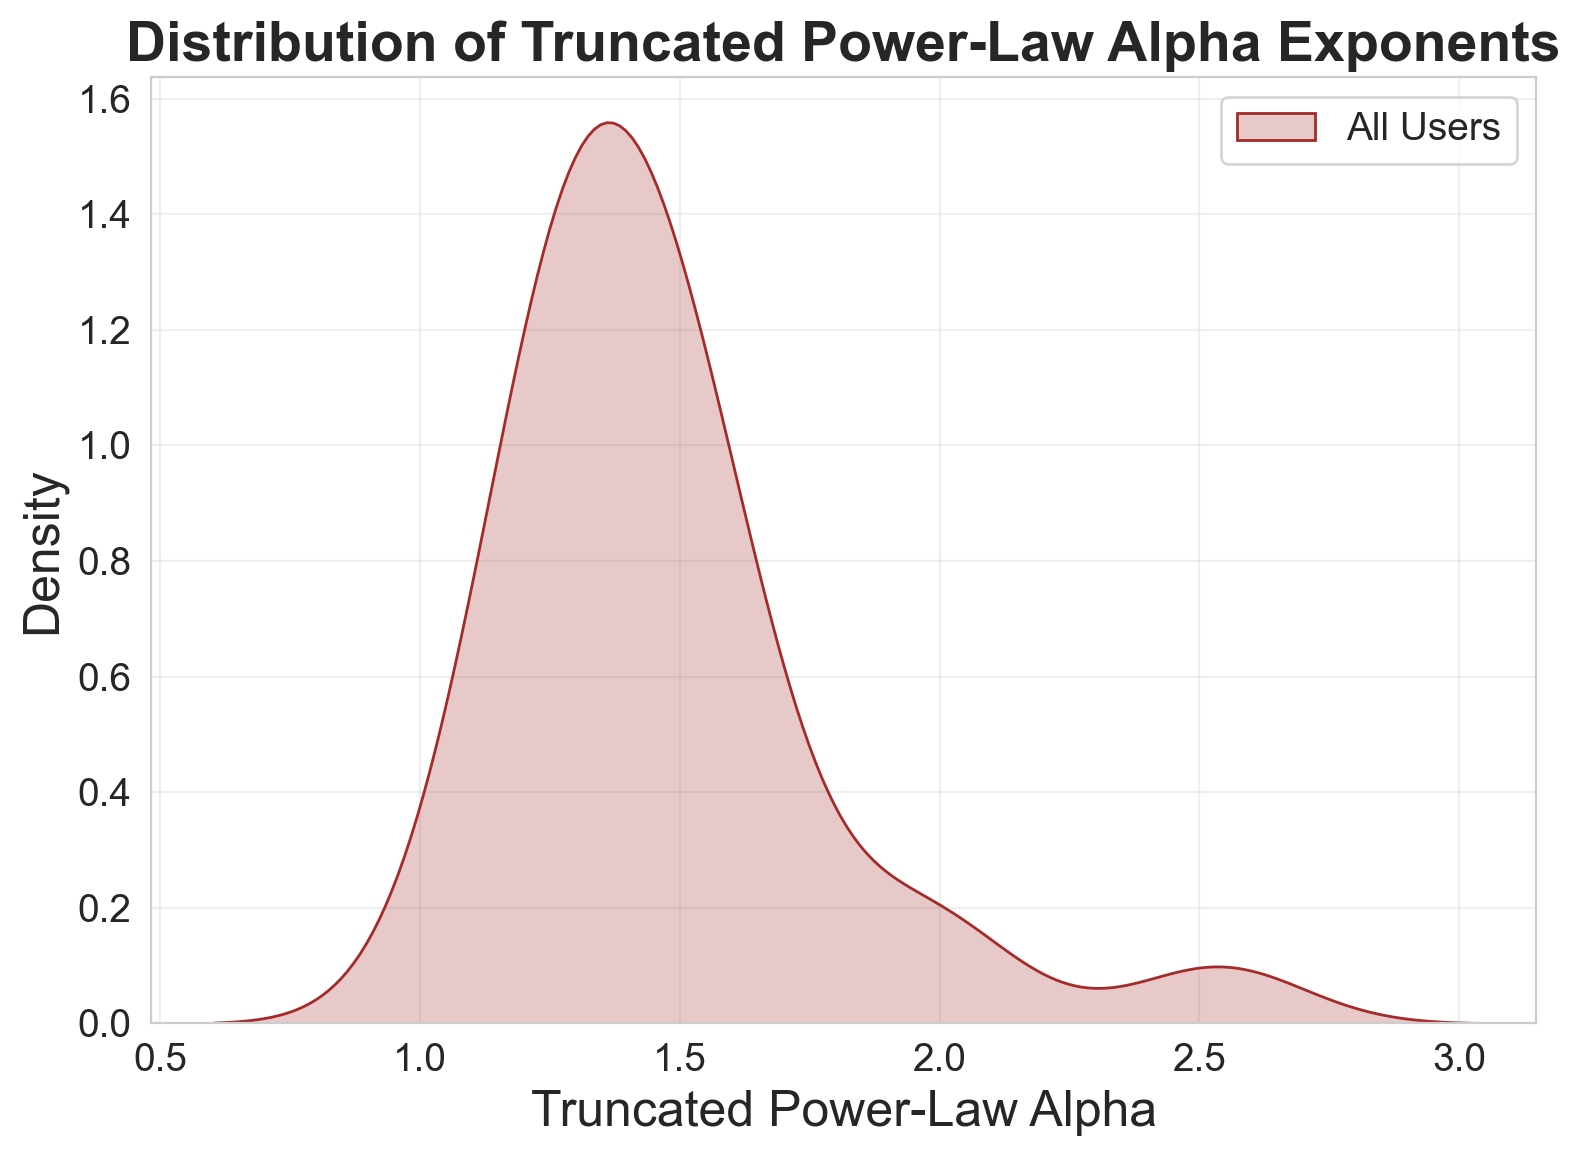

In [42]:
# Compare the truncated power-law exponents (alpha and lambda) across the three ideology groups for the active users, and plot the distributions of these exponents for each group.
def extract_truncated_power_law_params(active_users, messages_df):
    alphas = []
    lambdas = []
    for user in active_users:
        user_messages = messages_df[messages_df['sender_id'] == user] # Gather messages sent by the user.
        user_dates = pd.to_datetime(user_messages['date'], errors='coerce').dropna()
        waiting_time = user_dates.diff().dropna()
        fit_tpl = fit_truncated_power_law_report(waiting_time.dt.total_seconds(), f"User {user}", show_results=False, show_plots=False)
        if fit_tpl is not None:
            tpl = fit_tpl.truncated_power_law
            alphas.append(getattr(tpl, "alpha", np.nan))
            lambdas.append(getattr(tpl, "lambda_", np.nan))
    return alphas, lambdas
alphas, lambdas = extract_truncated_power_law_params(active_users, active_users_messages)
# Plot the distributions of alpha and lambda for each ideology group
plt.figure(figsize=(8,6))
sns.kdeplot(alphas, color='brown', label='All Users', fill=True)
plt.xlabel('Truncated Power-Law Alpha')
plt.ylabel('Density')
plt.title('Distribution of Truncated Power-Law Alpha Exponents')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

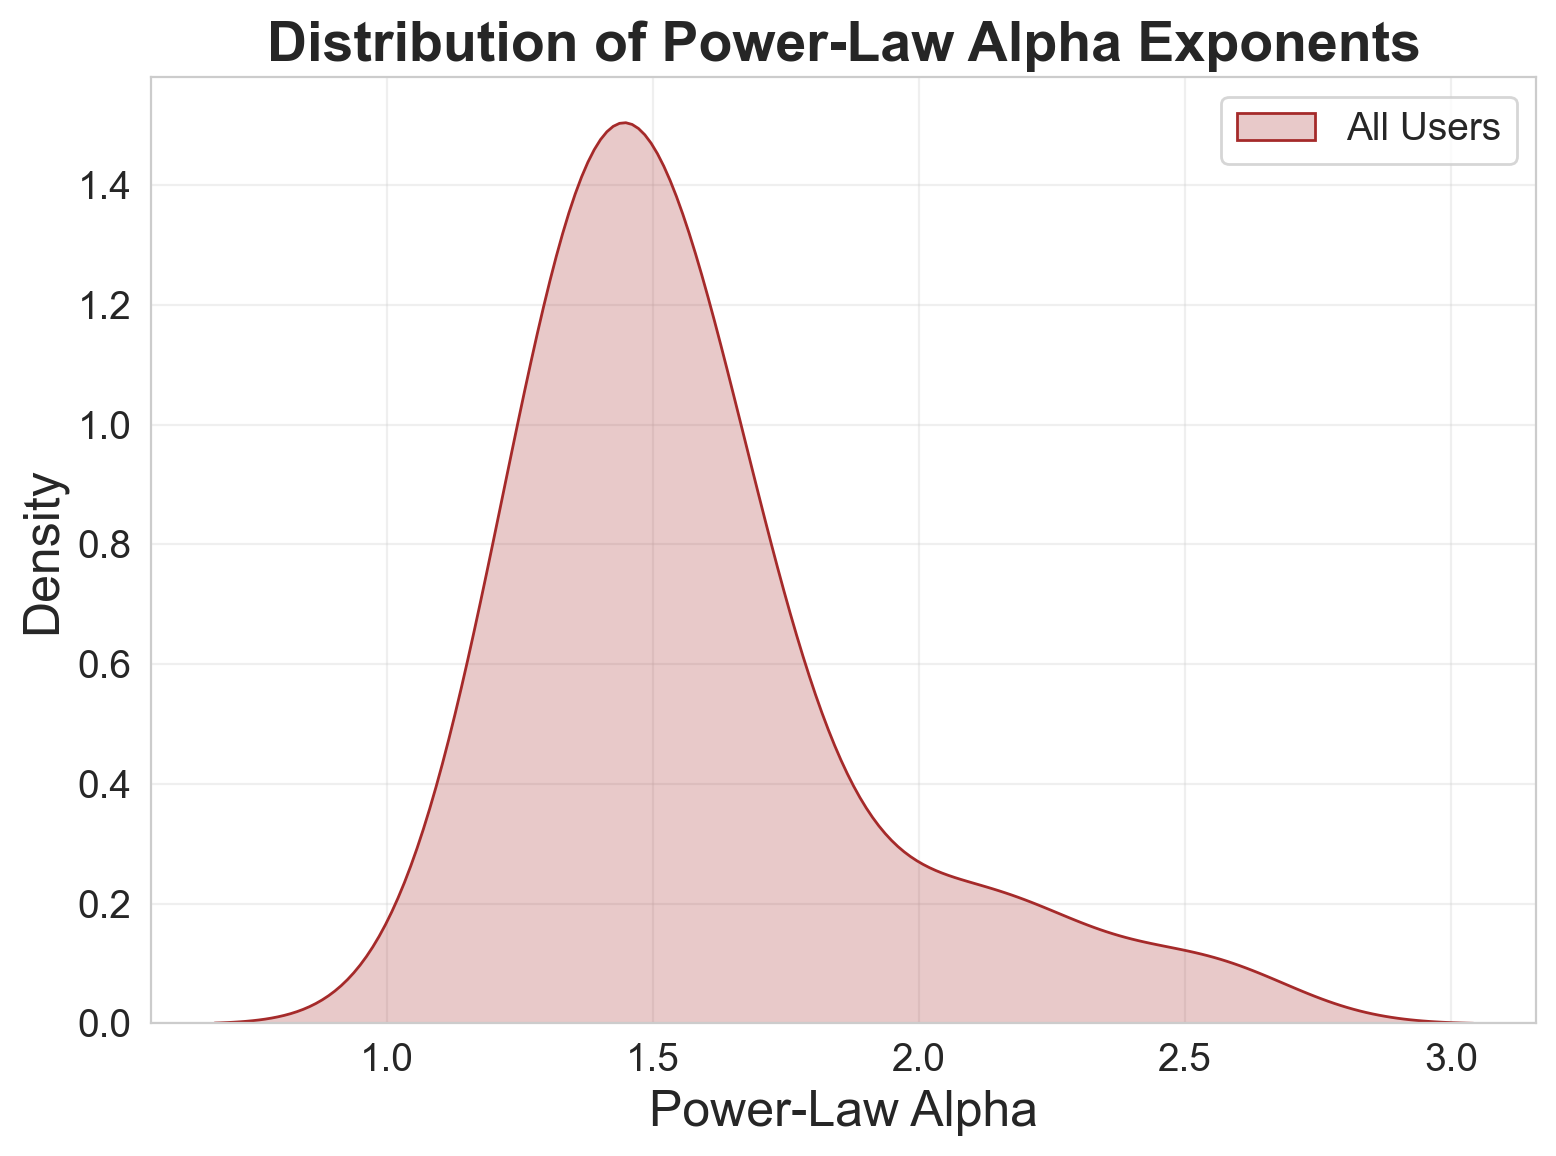

In [43]:
# Compare the normal power-law exponents (alpha and lambda) across the three ideology groups for the active users, and plot the distributions of these exponents for each group.
def extract_power_law_params(active_users, messages_df):
    alphas = []
    lambdas = []
    for user in active_users:
        user_messages = messages_df[messages_df['sender_id'] == user] # Gather messages sent by the user.
        user_dates = pd.to_datetime(user_messages['date'], errors='coerce').dropna()
        waiting_time = user_dates.diff().dropna()
        fit_tpl = fit_power_law_report(waiting_time.dt.total_seconds(), f"User {user}", show_results=False, show_plots=False)
        if fit_tpl is not None:
            tpl = fit_tpl.power_law
            alphas.append(getattr(tpl, "alpha", np.nan))
            lambdas.append(getattr(tpl, "lambda_", np.nan))
    return alphas, lambdas
alphas, lambdas = extract_power_law_params(active_users, active_users_messages)
plt.figure(figsize=(8,6))
sns.kdeplot(alphas, color='brown', label='All Users', fill=True)
plt.xlabel('Power-Law Alpha')
plt.ylabel('Density')
plt.title('Distribution of Power-Law Alpha Exponents')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Waiting times for users with over 50 messages and 5 days of activity.

In [44]:
# Gather users with 50 or more messages sent 
active_users_50 = df['sender_id'].value_counts()[df['sender_id'].value_counts() >= 50].index.tolist() # Gather sender IDs of users with 50 or more messages sent.
len(active_users_50)

50

In [45]:
active_users_messages_50 = df[df['sender_id'].isin(active_users_50)] # Filter the DataFrame to include only messages from active users.

In [46]:
active_users_50 = filter_users_by_activity(active_users_50, df, min_days=5) # Filter active users by a minimum period of activity of 5 days.
len(active_users_50)

37

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges

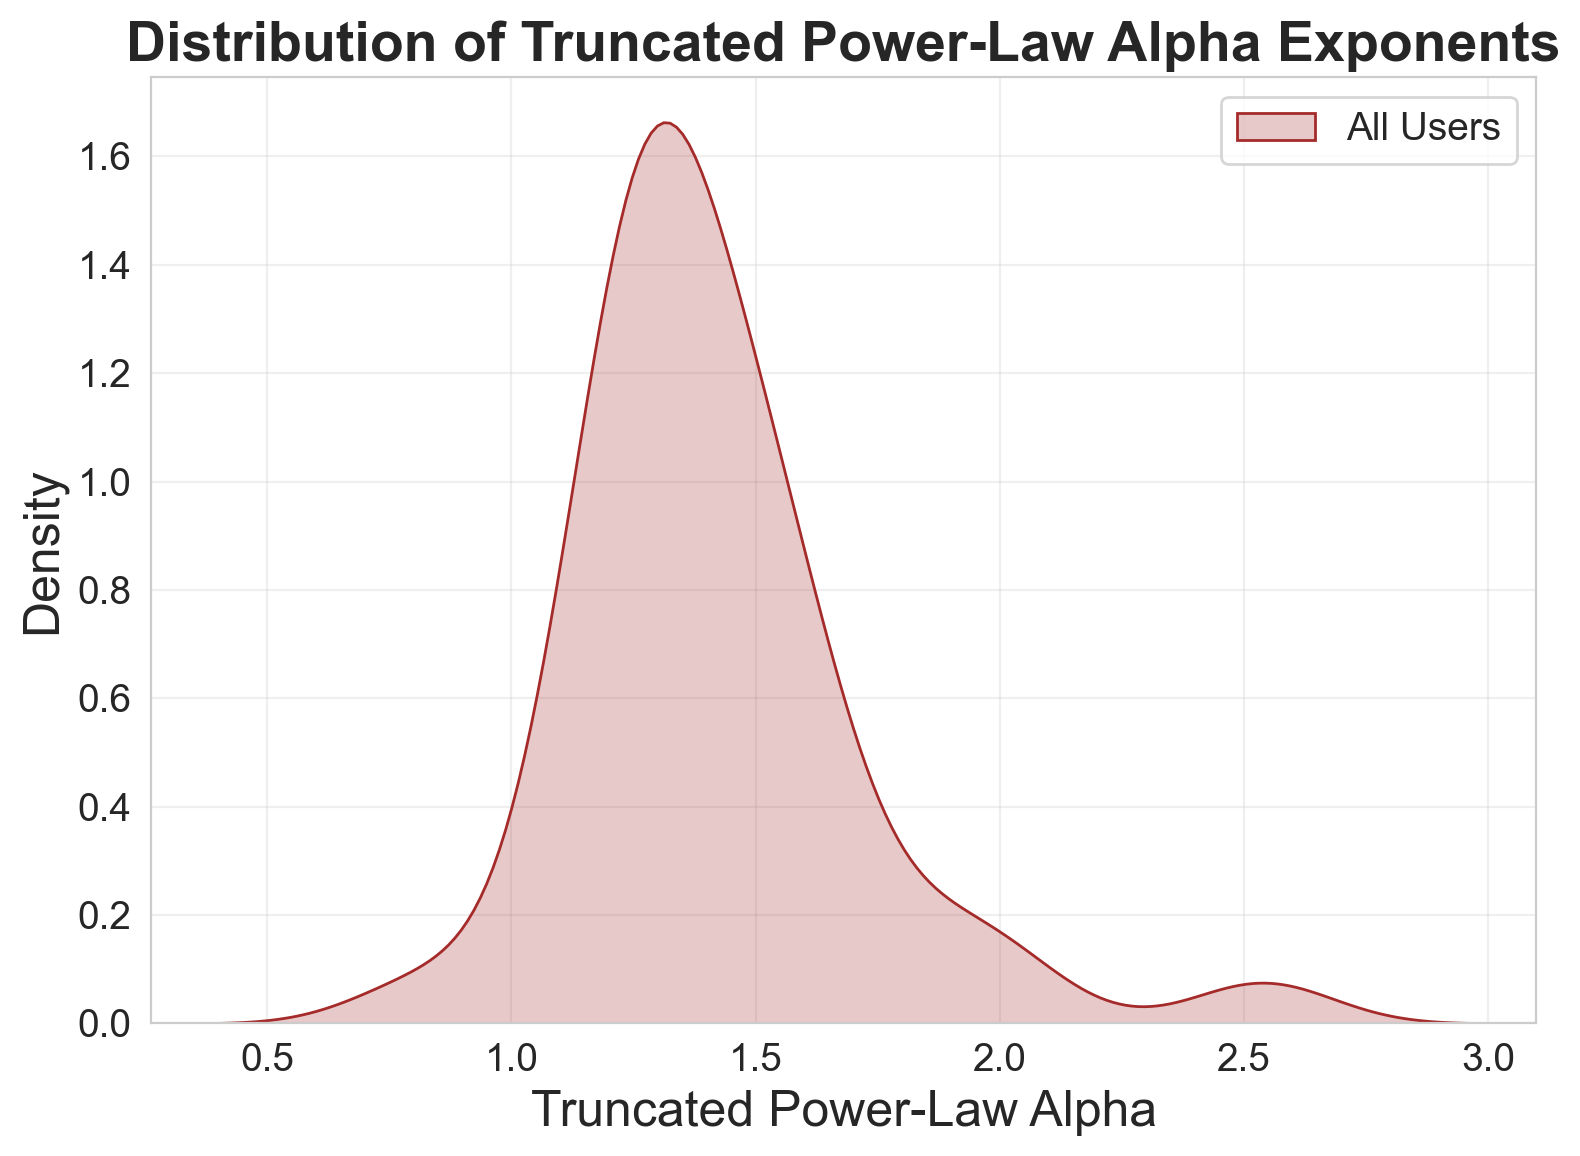

In [47]:
alphas_50, lambdas_50 = extract_truncated_power_law_params(active_users_50, active_users_messages_50)
# Plot the distributions of alpha and lambda for each ideology group
plt.figure(figsize=(8,6))
sns.kdeplot(alphas_50, color='brown', label='All Users', fill=True)
plt.xlabel('Truncated Power-Law Alpha')
plt.ylabel('Density')
plt.title('Distribution of Truncated Power-Law Alpha Exponents')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

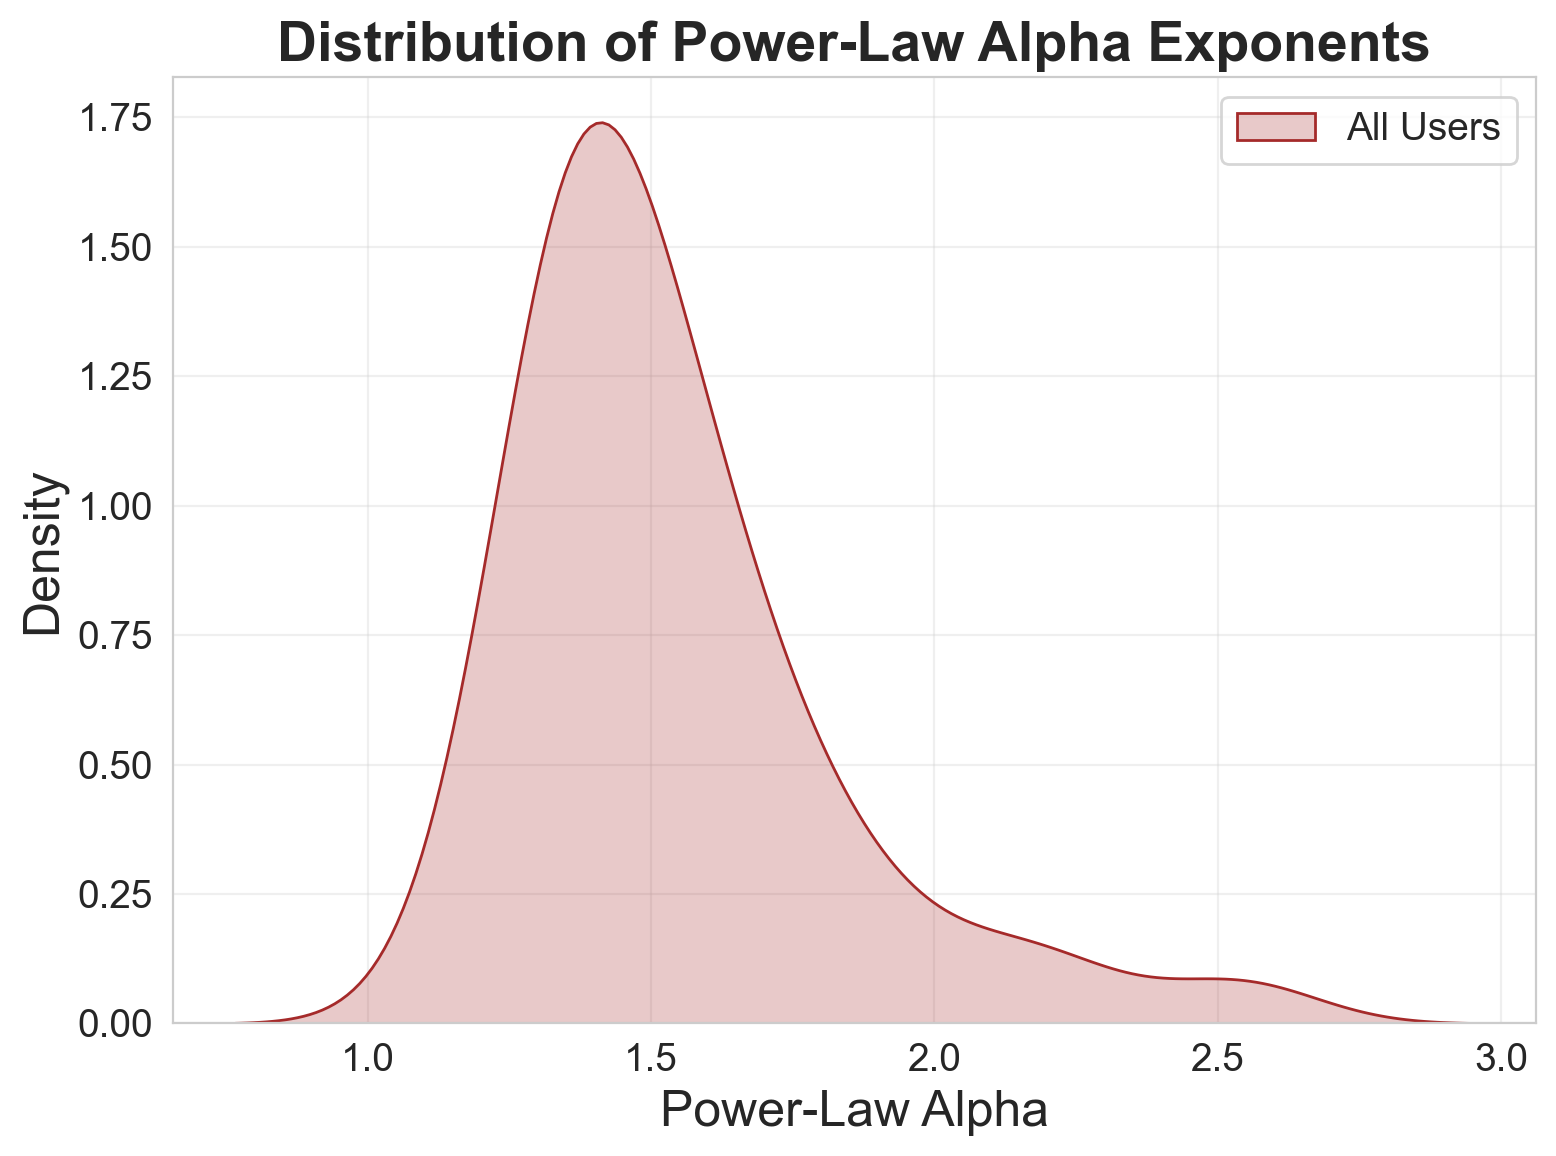

In [48]:
alphas_50, lambdas_50 = extract_power_law_params(active_users_50, active_users_messages_50)
plt.figure(figsize=(8,6))
sns.kdeplot(alphas_50, color='brown', label='All Users', fill=True)
plt.xlabel('Power-Law Alpha')
plt.ylabel('Density')
plt.title('Distribution of Power-Law Alpha Exponents')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Coordinators-User analysis

In [49]:
# Find potential coordinators by searching for "coordinador" in sender_name
coord_candidates = (
    df[df['sender_id'].isin(active_users_50)]
    .groupby('sender_id')
    .agg(
        sender_name=('sender_name', lambda x: x.dropna().mode().iloc[0] if not x.dropna().empty else 'Unknown'),
        n_messages=('id', 'count'),
        first_date=('date', 'min'),
        last_date=('date', 'max')
    )
)

coord_candidates['active_days'] = (coord_candidates['last_date'] - coord_candidates['first_date']).dt.days
coord_candidates = coord_candidates.sort_values(['n_messages', 'active_days'], ascending=[False, False])

# Filter for users with "coordinador" in their name (case-insensitive)
coord_candidates_filtered = coord_candidates[coord_candidates['sender_name'].str.contains('coordinador', case=False, na=False)]

print(f"Found {len(coord_candidates_filtered)} users with 'coordinador' in their name:")
print(coord_candidates_filtered)

print(f"\n\nTop 25 all users (for comparison):")
coord_candidates.head(25)

Found 1 users with 'coordinador' in their name:
                                         sender_name  n_messages  \
sender_id                                                          
1110241832  Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼         228   

                          first_date                 last_date  active_days  
sender_id                                                                    
1110241832 2024-10-30 12:39:24+00:00 2025-11-10 11:06:47+00:00          375  


Top 25 all users (for comparison):


,sender_name,n_messages,first_date,last_date,active_days
sender_id,,,,,
1762777403,David,441,2024-11-01 18:12:31+00:00,2024-12-24 11:38:52+00:00,52
7094531229,CarlosM,432,2024-11-01 15:47:42+00:00,2025-02-17 19:14:32+00:00,108
1505404600,Susana Ramirez,388,2024-11-02 13:06:26+00:00,2024-11-17 07:03:58+00:00,14
271855505,Esther,347,2024-10-31 15:55:43+00:00,2025-03-21 10:35:52+00:00,140
6973904485,Elena C. Álvarez,339,2024-11-02 19:29:22+00:00,2024-12-25 18:56:52+00:00,52
6601816159,Lara PM,298,2024-11-05 08:06:28+00:00,2024-12-15 16:40:36+00:00,40
6221273187,Chavela torres,278,2024-11-02 07:34:34+00:00,2024-11-15 00:47:34+00:00,12
1095473116,Víctor,237,2024-11-02 10:34:06+00:00,2024-11-09 23:12:55+00:00,7
5689570195,Ainara,232,2024-11-02 01:01:43+00:00,2025-02-14 07:53:32+00:00,104


In [50]:
# Username coordinators list (two coordinators were private and cannot be found).
coordinators_usernames = ['Marc_Nuba', 'LauAlejandro', 'Camelocota', 'MartaBalaguer', 'tipisibiza', 'Manuel_deRonde', 'CharlieWatchtower', 'ZRNATXO', 'docebocados', 'Esthx', 'AlcarolaGo']

# Build mapping sender_id -> sender_username (if available in the original df)
if 'sender_username' in df.columns:
    usernames = df[['sender_id','sender_username']].drop_duplicates().dropna(subset=['sender_username']).set_index('sender_id')['sender_username']
else:
    usernames = pd.Series(dtype=object)

# Map usernames into coord_candidates (index is sender_id)
coord_candidates['sender_username'] = coord_candidates.index.map(usernames).fillna('Unknown')

# Print columns to verify and show a sample
print('coord_candidates columns:', coord_candidates.columns.tolist())
print(coord_candidates.head())

# Try to find known coordinators by mapped username
coordinators_info = coord_candidates[coord_candidates['sender_username'].isin(coordinators_usernames)]
if not coordinators_info.empty:
    print('Information about known coordinators found in coord_candidates:')
    print(coordinators_info)
else:
    print('No coordinators found by username in coord_candidates. Falling back to df-based lookup (by sender_username -> sender_id):')
    for username in coordinators_usernames:
        if 'sender_username' not in df.columns:
            print(f"Warning: df has no 'sender_username' column to look up {username}.")
            continue
        matched_ids = df[df['sender_username'] == username]['sender_id'].unique()
        if len(matched_ids) == 0:
            print(f"Warning: Coordinator username '{username}' not found in df.")
            continue
        for sid in matched_ids:
            if sid in coord_candidates.index:
                row = coord_candidates.loc[sid]
                num_messages = row['n_messages']
                period_of_activity = row['active_days']
                print(f"Coordinator '{username}' (sender_id={sid}) found with {num_messages} messages and {period_of_activity} days of activity.")
            else:
                print(f"Coordinator '{username}' (sender_id={sid}) not present among filtered active users.")




coord_candidates columns: ['sender_name', 'n_messages', 'first_date', 'last_date', 'active_days', 'sender_username']
                 sender_name  n_messages                first_date  \
sender_id                                                            
1762777403             David         441 2024-11-01 18:12:31+00:00   
7094531229           CarlosM         432 2024-11-01 15:47:42+00:00   
1505404600    Susana Ramirez         388 2024-11-02 13:06:26+00:00   
271855505             Esther         347 2024-10-31 15:55:43+00:00   
6973904485  Elena C. Álvarez         339 2024-11-02 19:29:22+00:00   

                           last_date  active_days sender_username  
sender_id                                                          
1762777403 2024-12-24 11:38:52+00:00           52       DavidBCNn  
7094531229 2025-02-17 19:14:32+00:00          108         Unknown  
1505404600 2024-11-17 07:03:58+00:00           14      tipisibiza  
271855505  2025-03-21 10:35:52+00:00          140   

In [51]:
# find sender_id for coordinators by username in the original df
coordinators_id = {}
for username in coordinators_usernames:
    if 'sender_username' not in df.columns:
        print(f"Warning: df has no 'sender_username' column to look up {username}.")
        continue
    matched_ids = df[df['sender_username'] == username]['sender_id'].unique()
    if len(matched_ids) == 0:
        print(f"Warning: Coordinator username '{username}' not found in df.")
        continue
    coordinators_id[username] = matched_ids[0]  # Assuming the first match is the correct one
print("Coordinators found with their sender_id:")
for username, sender_id in coordinators_id.items():
    print(f"{username}: sender_id={sender_id}")

coordinators_users = df[df['sender_id'].isin(coordinators_id.values())][['sender_id', 'sender_username']].drop_duplicates()
coordinators_messages = df[df['sender_id'].isin(coordinators_id.values())] # Filter the DataFrame to include only messages from active users.

Coordinators found with their sender_id:
Marc_Nuba: sender_id=5782910539
LauAlejandro: sender_id=1065332141
Camelocota: sender_id=941865373
MartaBalaguer: sender_id=602365744
tipisibiza: sender_id=1505404600
Manuel_deRonde: sender_id=1110241832
CharlieWatchtower: sender_id=1568971431
ZRNATXO: sender_id=7154226214
docebocados: sender_id=1013002212
Esthx: sender_id=271855505
AlcarolaGo: sender_id=6601816159


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges

User 941865373: Not enough data to fit reliably (n=14).


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges

User 1568971431: Not enough data to fit reliably (n=5).
User 7154226214: Not enough data to fit reliably (n=13).


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges

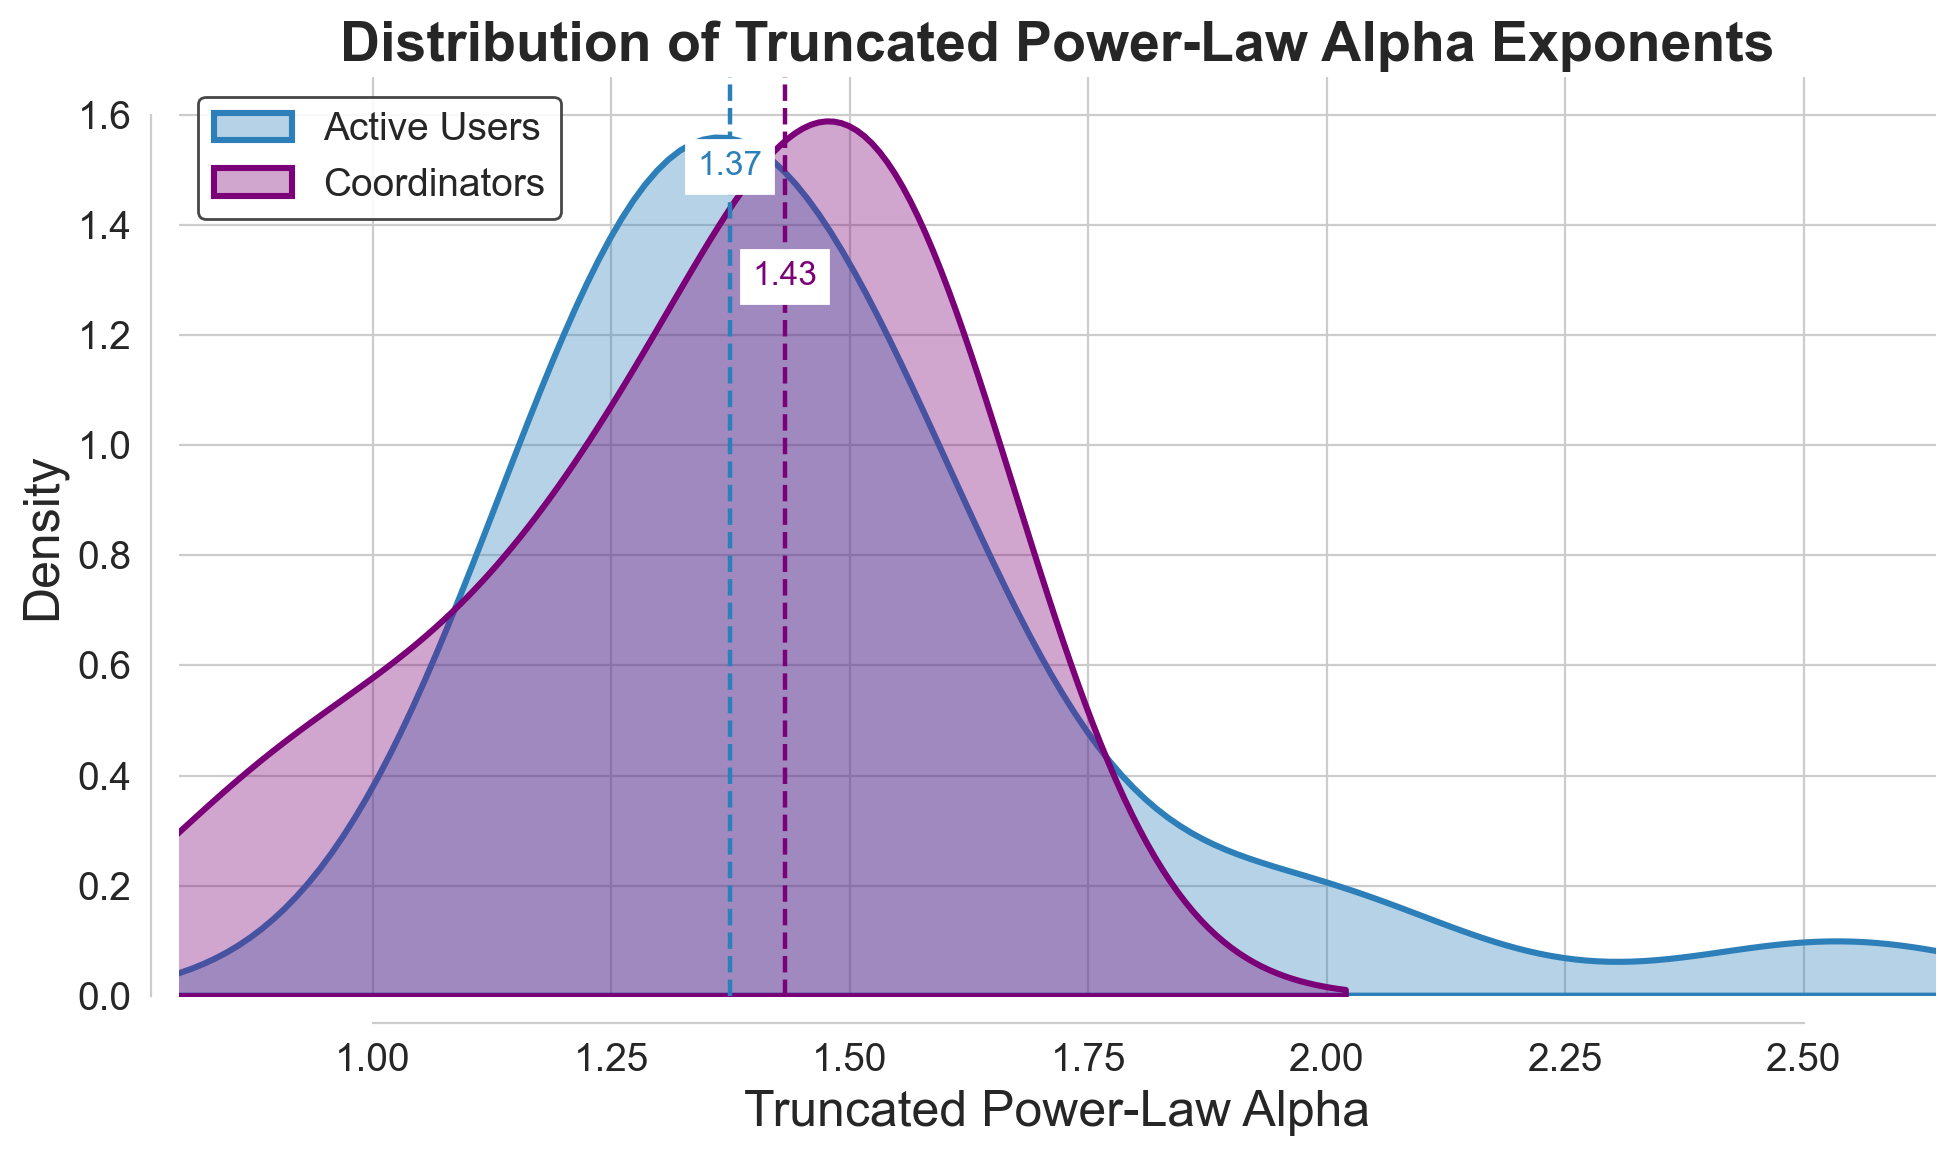

In [52]:
# Waiting times for the coordinators

import matplotlib as mpl
sns.set_style('whitegrid')
mpl.rcParams.update({
    'figure.dpi': 200,
    'font.size': 14,
    'axes.titlesize': 20,
    'axes.labelsize': 18,
    'legend.fontsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'axes.titleweight': 'bold',
})

alphas_au, lambdas_au = extract_truncated_power_law_params(active_users, active_users_messages)
alphas_coord, lambdas_coord = extract_truncated_power_law_params(coordinators_id.values(), coordinators_messages)

# Define clear, high-contrast colors (avoid green and orange)
blue = '#2c7fb8'   # deep blue
purple = '#7a0177' # deep magenta

# Prepare arrays (handle empty cases)
au = np.asarray(alphas_au) if alphas_au is not None else np.array([])
coord = np.asarray(alphas_coord) if alphas_coord is not None else np.array([])

fig, ax = plt.subplots(figsize=(10,6), dpi=200)

# Compute sensible x-limits with padding
valid_vals = np.concatenate([au[~np.isnan(au)] if au.size else np.array([]), coord[~np.isnan(coord)] if coord.size else np.array([])])
if valid_vals.size > 0:
    xmin, xmax = np.min(valid_vals), np.max(valid_vals)
    pad = max(0.06 * (xmax - xmin), 0.1)
    ax.set_xlim(xmin - pad, xmax + pad)
else:
    ax.set_xlim(0.5, 3.0)

# Plot KDEs with thicker lines and translucent fills
if au.size:
    sns.kdeplot(au, ax=ax, color=blue, fill=True, alpha=0.35, linewidth=2.2, label='Active Users', bw_method='scott')
if coord.size:
    sns.kdeplot(coord, ax=ax, color=purple, fill=True, alpha=0.35, linewidth=2.2, label='Coordinators', bw_method='scott')

# Add median lines and annotations for readability
ymax = ax.get_ylim()[1]
if au.size:
    med_au = np.nanmedian(au)
    ax.axvline(med_au, color=blue, linestyle='--', linewidth=1.6)
    ax.text(med_au, ymax * 0.92, f'{med_au:.2f}', color=blue, fontsize=12, ha='center', va='top', backgroundcolor='white')
if coord.size:
    med_coord = np.nanmedian(coord)
    ax.axvline(med_coord, color=purple, linestyle='--', linewidth=1.6)
    ax.text(med_coord, ymax * 0.80, f'{med_coord:.2f}', color=purple, fontsize=12, ha='center', va='top', backgroundcolor='white')

# Labels and title
ax.set_xlabel('Truncated Power-Law Alpha', fontsize=18)
ax.set_ylabel('Density', fontsize=18)
ax.set_title('Distribution of Truncated Power-Law Alpha Exponents', fontsize=20, weight='bold')

# Legend styling
leg = ax.legend(frameon=True, facecolor='white', edgecolor='0.2', framealpha=0.9, loc='upper left')
for text in leg.get_texts():
    text.set_fontsize(14)

# Improve ticks and spines
ax.tick_params(axis='both', which='major', labelsize=14)
sns.despine(trim=True, offset=10)

plt.tight_layout()
plt.show()

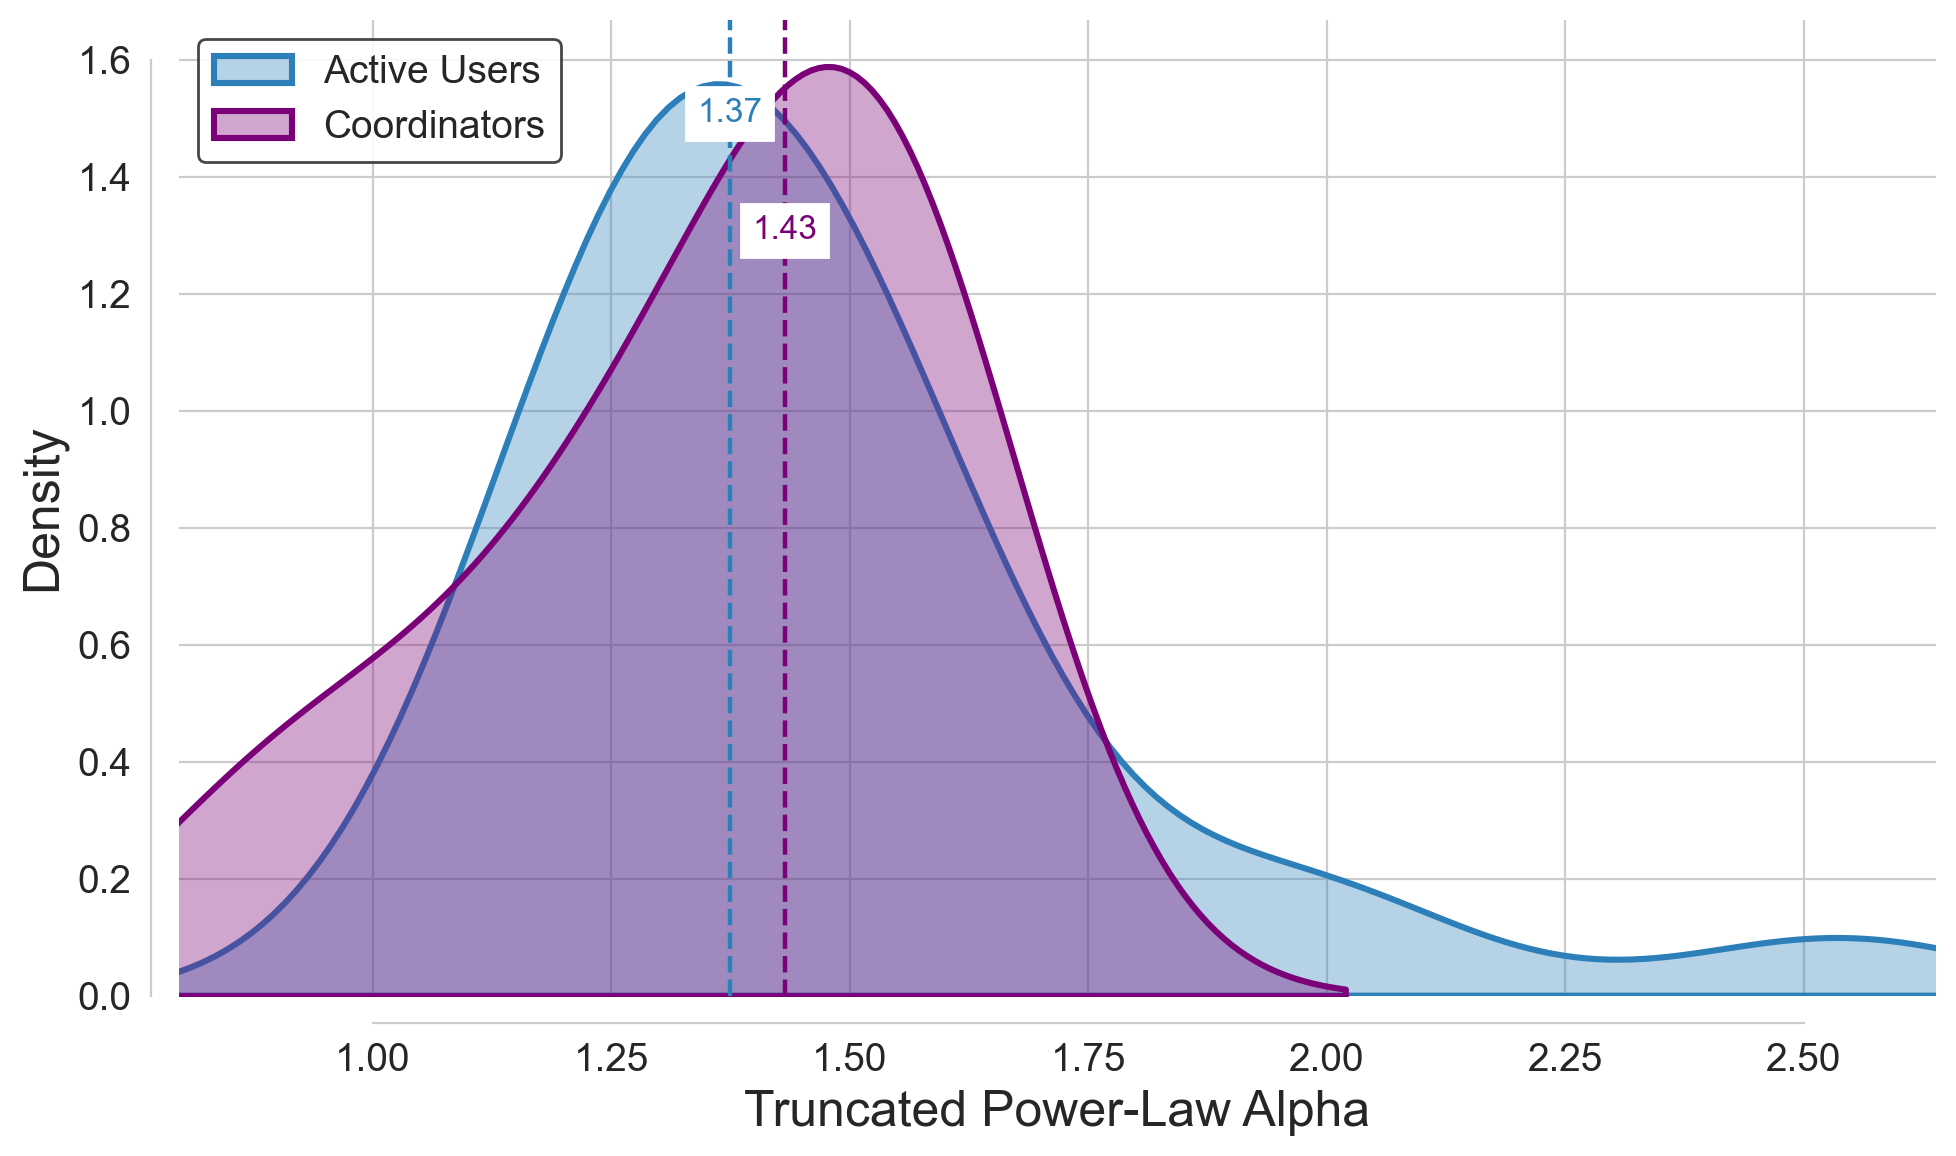

In [53]:
# Plot the distributions of alpha and lambda for each ideology group (improved styling for poster)
import matplotlib as mpl
sns.set_style('whitegrid')
mpl.rcParams.update({
    'figure.dpi': 200,
    'font.size': 14,
    'axes.titlesize': 20,
    'axes.labelsize': 18,
    'legend.fontsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'axes.titleweight': 'bold',
})

# Colors (avoid green and orange)
blue = '#2c7fb8'
purple = '#7a0177'

fig, ax = plt.subplots(figsize=(10,6), dpi=200)
au = np.asarray(alphas_au) if alphas_au is not None else np.array([])
coord = np.asarray(alphas_coord) if alphas_coord is not None else np.array([])
valid_vals = np.concatenate([au[~np.isnan(au)] if au.size else np.array([]), coord[~np.isnan(coord)] if coord.size else np.array([])])
if valid_vals.size > 0:
    xmin, xmax = np.min(valid_vals), np.max(valid_vals)
    pad = max(0.06 * (xmax - xmin), 0.1)
    ax.set_xlim(xmin - pad, xmax + pad)
else:
    ax.set_xlim(0.5, 3.0)

# KDE plots
if au.size:
    sns.kdeplot(au, ax=ax, color=blue, fill=True, alpha=0.35, linewidth=2.2, label='Active Users', bw_method='scott')
if coord.size:
    sns.kdeplot(coord, ax=ax, color=purple, fill=True, alpha=0.35, linewidth=2.2, label='Coordinators', bw_method='scott')

# Median lines and annotation
ymax = ax.get_ylim()[1]
if au.size:
    med_au = np.nanmedian(au)
    ax.axvline(med_au, color=blue, linestyle='--', linewidth=1.6)
    ax.text(med_au, ymax * 0.92, f'{med_au:.2f}', color=blue, fontsize=12, ha='center', va='top', backgroundcolor='white')
if coord.size:
    med_coord = np.nanmedian(coord)
    ax.axvline(med_coord, color=purple, linestyle='--', linewidth=1.6)
    ax.text(med_coord, ymax * 0.80, f'{med_coord:.2f}', color=purple, fontsize=12, ha='center', va='top', backgroundcolor='white')

ax.set_xlabel('Truncated Power-Law Alpha', fontsize=18)
ax.set_ylabel('Density', fontsize=18)
#ax.set_title('Distribution of Truncated Power-Law Alpha Exponents', fontsize=20, weight='bold')

leg = ax.legend(frameon=True, facecolor='white', edgecolor='0.2', framealpha=0.9, loc='upper left')
for text in leg.get_texts():
    text.set_fontsize(14)

ax.tick_params(axis='both', which='major', labelsize=14)
sns.despine(trim=True, offset=10)
plt.tight_layout()
plt.show()

In [54]:
# Recreate the poster-ready figure and save to PNG and SVG (robust exporter)
import os
import matplotlib as mpl
sns.set_style('whitegrid')
mpl.rcParams.update({
    'figure.dpi': 200,
    'font.size': 14,
    'axes.titlesize': 20,
    'axes.labelsize': 18,
    'legend.fontsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'axes.titleweight': 'bold',
})

def save_truncated_alpha_fig(out_dir='figures', png_name='truncated_powerlaw_alpha.png', svg_name='truncated_powerlaw_alpha.svg', dpi=600):
    os.makedirs(out_dir, exist_ok=True)
    # Recompute the alpha arrays (safe to call multiple times)
    alphas_au, _ = extract_truncated_power_law_params(active_users, active_users_messages)
    alphas_coord, _ = extract_truncated_power_law_params(coordinators_id.values(), coordinators_messages)
    au = np.asarray(alphas_au) if alphas_au is not None else np.array([])
    coord = np.asarray(alphas_coord) if alphas_coord is not None else np.array([])

    # Colors (avoid green and orange)
    blue = '#2c7fb8'
    purple = '#7a0177'

    fig, ax = plt.subplots(figsize=(10,6), dpi=200)

    # Compute sensible x-limits with padding
    valid_vals = np.concatenate([au[~np.isnan(au)] if au.size else np.array([]), coord[~np.isnan(coord)] if coord.size else np.array([])])
    if valid_vals.size > 0:
        xmin, xmax = np.min(valid_vals), np.max(valid_vals)
        pad = max(0.06 * (xmax - xmin), 0.1)
        ax.set_xlim(xmin - pad, xmax + pad)
    else:
        ax.set_xlim(0.5, 3.0)

    # KDE plots
    if au.size:
        sns.kdeplot(au, ax=ax, color=blue, fill=True, alpha=0.35, linewidth=2.2, label='Active Users', bw_method='scott')
    if coord.size:
        sns.kdeplot(coord, ax=ax, color=purple, fill=True, alpha=0.35, linewidth=2.2, label='Coordinators', bw_method='scott')

    # Median lines and annotation
    ymax = ax.get_ylim()[1]
    if au.size:
        med_au = np.nanmedian(au)
        ax.axvline(med_au, color=blue, linestyle='--', linewidth=1.6)
        ax.text(med_au, ymax * 0.92, f'{med_au:.2f}', color='white', fontsize=12, ha='center', va='top', bbox=dict(facecolor=blue, edgecolor='none', boxstyle='round,pad=0.3'))
    if coord.size:
        med_coord = np.nanmedian(coord)
        ax.axvline(med_coord, color=purple, linestyle='--', linewidth=1.6)
        ax.text(med_coord, ymax * 0.80, f'{med_coord:.2f}', color='white', fontsize=12, ha='center', va='top', bbox=dict(facecolor=purple, edgecolor='none', boxstyle='round,pad=0.3'))

    ax.set_xlabel('Truncated Power-Law Alpha', fontsize=18)
    ax.set_ylabel('Density', fontsize=18)
    #ax.set_title('Distribution of Truncated Power-Law Alpha Exponents', fontsize=20, weight='bold')

    leg = ax.legend(frameon=True, facecolor='white', edgecolor='0.2', framealpha=0.9, loc='upper left')
    for text in leg.get_texts():
        text.set_fontsize(14)

    ax.tick_params(axis='both', which='major', labelsize=14)
    sns.despine(trim=True, offset=10)

    png_path = os.path.join(out_dir, png_name)
    svg_path = os.path.join(out_dir, svg_name)
    fig.savefig(png_path, dpi=dpi, bbox_inches='tight')
    fig.savefig(svg_path, dpi=dpi, bbox_inches='tight')
    plt.close(fig)
    print(f'Saved PNG: {png_path}')
    print(f'Saved SVG: {svg_path}')

# Usage: run this cell (or call save_truncated_alpha_fig()) after any data cells are executed
save_truncated_alpha_fig()

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges

User 941865373: Not enough data to fit reliably (n=14).


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges

User 1568971431: Not enough data to fit reliably (n=5).
User 7154226214: Not enough data to fit reliably (n=13).


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges

Saved PNG: figures/truncated_powerlaw_alpha.png
Saved SVG: figures/truncated_powerlaw_alpha.svg


### Maximum waiting time per user

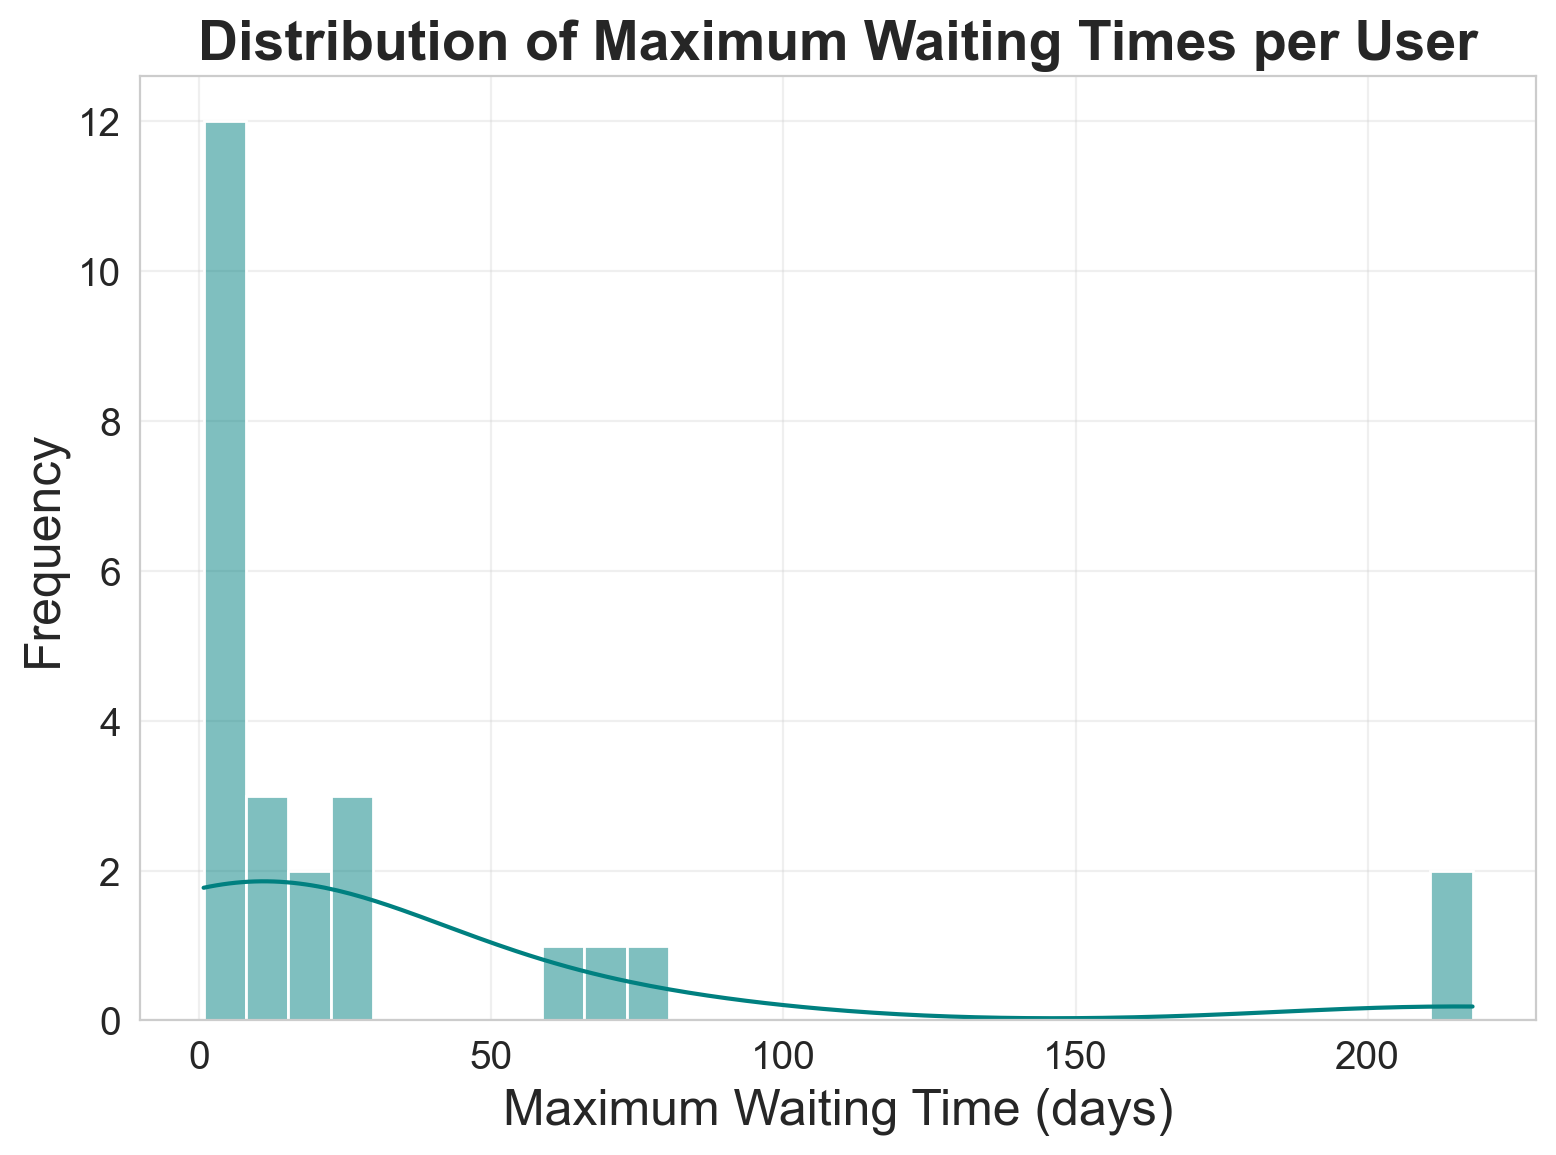

Total number of days the chat was active: 375


In [55]:
# maximum waiting time for each user
def max_waiting_time_per_user(active_users, messages_df):
    max_waiting_times = {}
    for user in active_users:
        user_messages = messages_df[messages_df['sender_id'] == user] # Gather messages sent by the user.
        user_dates = pd.to_datetime(user_messages['date'], errors='coerce').dropna()
        if len(user_dates) < 2:
            continue
        waiting_time = user_dates.diff().dropna()
        max_waiting_times[user] = waiting_time.max().total_seconds()/86400 # Convert to days
    return max_waiting_times
max_waiting_times = max_waiting_time_per_user(active_users, active_users_messages)
# Plot the distribution of maximum waiting times
plt.figure(figsize=(8,6))
sns.histplot(list(max_waiting_times.values()), bins=30, kde=True, color='teal')
plt.xlabel('Maximum Waiting Time (days)')
plt.ylabel('Frequency')
plt.title('Distribution of Maximum Waiting Times per User')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Total number of days the chat was active:", (df['date'].max() - df['date'].min()).days)

## Finite size bias

In [56]:
from lifelines import KaplanMeierFitter
from scipy.optimize import curve_fit

date_tz = df['date'].dt.tz
cutoff_date = df['date'].max()  # global end of dataset — users who left contribute a long censored IET


def extract_pl_params_km(users, messages_df, cutoff):
    alphas_km = []
    for user in users:
        user_msgs = messages_df[messages_df['sender_id'] == user]
        user_dates = pd.to_datetime(user_msgs['date'], errors='coerce').dropna().sort_values()
        if len(user_dates) < 10:
            continue
        waiting = user_dates.diff().dt.total_seconds().dropna()
        waiting = waiting[(waiting > 0) & np.isfinite(waiting)].values
        if len(waiting) < 10:
            continue

        tau_fc = max((cutoff - user_dates.iloc[-1]).total_seconds(), 0.0)
        km_dur = np.concatenate([waiting, waiting, [tau_fc]])
        km_obs = np.concatenate([np.ones(len(waiting)), np.ones(len(waiting)), [0]])
        kmf = KaplanMeierFitter()
        kmf.fit(km_dur, event_observed=km_obs.astype(bool))

        fit  = powerlaw.Fit(waiting, discrete=True, verbose=False)
        xmin = float(getattr(fit.power_law, 'xmin', np.nan))

        km_t = kmf.survival_function_.index.values
        km_s = kmf.survival_function_['KM_estimate'].values
        mask = (km_t >= xmin) & (km_s > 0) & (km_t > 0)
        if np.isfinite(xmin) and mask.sum() > 5:
            slope, _ = np.polyfit(np.log(km_t[mask]), np.log(km_s[mask]), 1)
            alphas_km.append(float(1.0 - slope))
    return alphas_km


def extract_tpl_params_km(users, messages_df, cutoff):
    alphas_tpl_km = []
    for user in users:
        user_msgs = messages_df[messages_df['sender_id'] == user]
        user_dates = pd.to_datetime(user_msgs['date'], errors='coerce').dropna().sort_values()
        if len(user_dates) < 10:
            continue
        waiting = user_dates.diff().dt.total_seconds().dropna()
        waiting = waiting[(waiting > 0) & np.isfinite(waiting)].values
        if len(waiting) < 10:
            continue

        tau_fc = max((cutoff - user_dates.iloc[-1]).total_seconds(), 0.0)
        km_dur = np.concatenate([waiting, waiting, [tau_fc]])
        km_obs = np.concatenate([np.ones(len(waiting)), np.ones(len(waiting)), [0]])
        kmf = KaplanMeierFitter()
        kmf.fit(km_dur, event_observed=km_obs.astype(bool))

        fit      = powerlaw.Fit(waiting, discrete=True, verbose=False)
        xmin     = float(getattr(fit.truncated_power_law, 'xmin', np.nan))
        alpha_r  = float(getattr(fit.truncated_power_law, 'alpha', np.nan))

        km_t = kmf.survival_function_.index.values
        km_s = kmf.survival_function_['KM_estimate'].values
        mask_tail = (km_t >= xmin) & (km_s > 0)
        if not np.isfinite(xmin) or mask_tail.sum() < 5:
            continue

        km_t_tail  = km_t[mask_tail]
        s_at_xmin  = float(np.interp(xmin, km_t, km_s))
        if s_at_xmin <= 0:
            continue
        km_s_norm = km_s[mask_tail] / s_at_xmin

        def tpl_surv(t, alpha, lam):
            return (t / xmin) ** (-(alpha - 1)) * np.exp(-(t - xmin) * lam)
        try:
            popt, _ = curve_fit(
                tpl_surv, km_t_tail, km_s_norm,
                p0=[max(alpha_r, 1.01), 1.0 / waiting.max()],
                bounds=([1.001, 0.0], [20.0, np.inf]), maxfev=10000
            )
            alphas_tpl_km.append(float(popt[0]))
        except Exception:
            continue
    return alphas_tpl_km

In [57]:
# PL KM-corrected (log-log on KM survival curve)
alphas_au_pl_km    = extract_pl_params_km(active_users, active_users_messages, cutoff_date)
alphas_coord_pl_km = extract_pl_params_km(coordinators_id.values(), coordinators_messages, cutoff_date)

# TPL KM-corrected (curve_fit on KM survival curve)
alphas_au_tpl_km    = extract_tpl_params_km(active_users, active_users_messages, cutoff_date)
alphas_coord_tpl_km = extract_tpl_params_km(coordinators_id.values(), coordinators_messages, cutoff_date)

# Raw PL alphas (no KM) for comparison
def _raw_pl(users, messages_df):
    alphas = []
    for user in users:
        msgs = messages_df[messages_df['sender_id'] == user]
        dates = pd.to_datetime(msgs['date'], errors='coerce').dropna().sort_values()
        if len(dates) < 10:
            continue
        w = dates.diff().dt.total_seconds().dropna()
        w = w[(w > 0) & np.isfinite(w)].values
        if len(w) < 10:
            continue
        fit = powerlaw.Fit(w, discrete=True, verbose=False)
        a = float(getattr(fit.power_law, 'alpha', np.nan))
        if np.isfinite(a):
            alphas.append(a)
    return alphas

alphas_au_pl_raw    = _raw_pl(active_users, active_users_messages)
alphas_coord_pl_raw = _raw_pl(coordinators_id.values(), coordinators_messages)

print(f"PL  — raw: AU={len(alphas_au_pl_raw)}, coord={len(alphas_coord_pl_raw)}")
print(f"PL  — KM:  AU={len(alphas_au_pl_km)}, coord={len(alphas_coord_pl_km)}")
print(f"TPL — raw (cell 24): AU={len(alphas_au) if alphas_au else 0}, coord={len(alphas_coord) if alphas_coord else 0}")
print(f"TPL — KM:  AU={len(alphas_au_tpl_km)}, coord={len(alphas_coord_tpl_km)}")


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges

PL  — raw: AU=25, coord=10
PL  — KM:  AU=25, coord=10
TPL — raw (cell 24): AU=25, coord=8
TPL — KM:  AU=25, coord=10


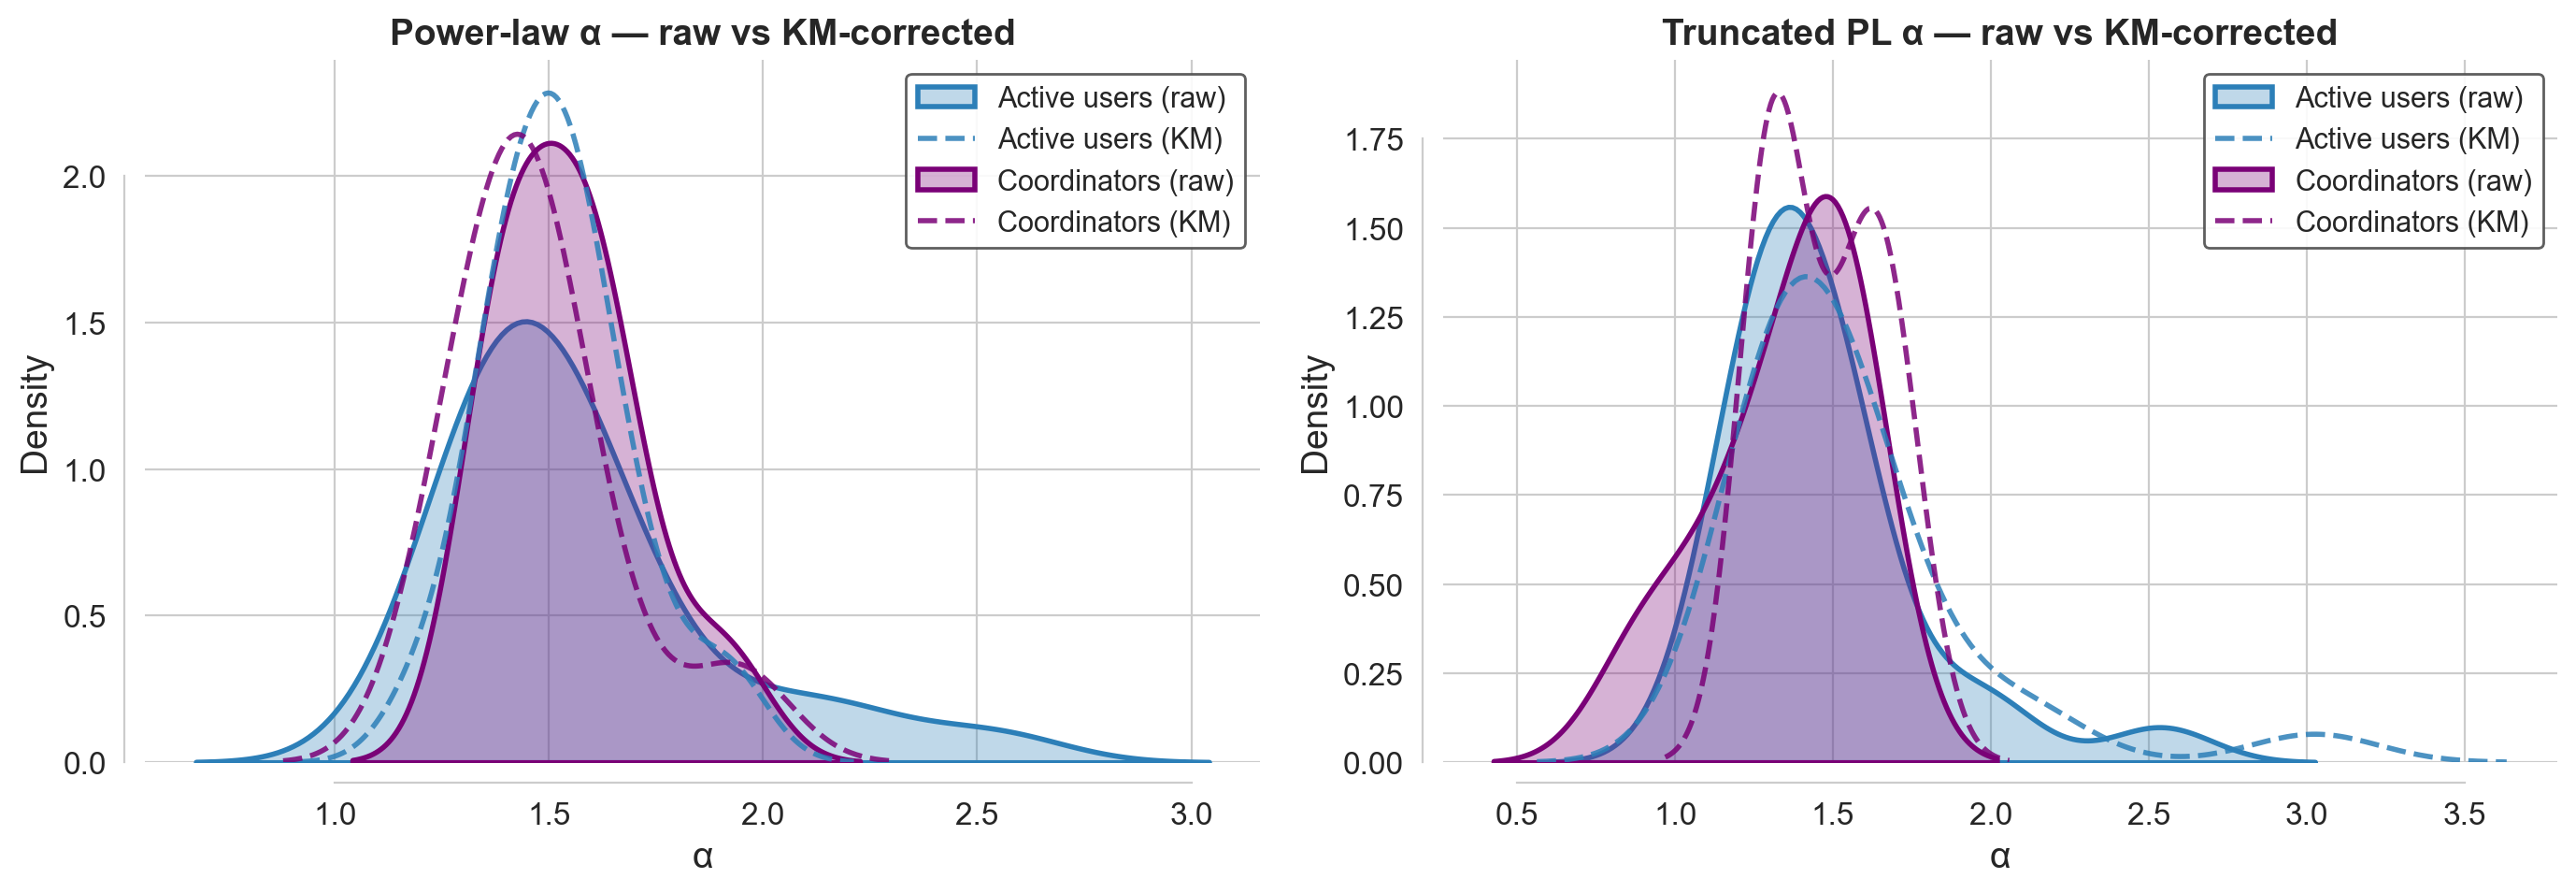

In [58]:
blue   = '#2c7fb8'
purple = '#7a0177'

with plt.rc_context({
    'figure.dpi': 200, 'font.size': 14, 'axes.titlesize': 15,
    'axes.labelsize': 14, 'legend.fontsize': 12,
    'xtick.labelsize': 12, 'ytick.labelsize': 12,
}):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=200)

    panels = [
        (
            np.asarray(alphas_au_pl_raw),    np.asarray(alphas_au_pl_km),
            np.asarray(alphas_coord_pl_raw), np.asarray(alphas_coord_pl_km),
            "Power-law α — raw vs KM-corrected",
        ),
        (
            np.asarray(alphas_au)    if alphas_au    else np.array([]),
            np.asarray(alphas_au_tpl_km),
            np.asarray(alphas_coord) if alphas_coord else np.array([]),
            np.asarray(alphas_coord_tpl_km),
            "Truncated PL α — raw vs KM-corrected",
        ),
    ]

    for ax, (raw_au, km_au, raw_co, km_co, title) in zip(axes, panels):
        for vals, color, ls, fill, alpha, lbl in [
            (raw_au, blue,   "-",  True,  0.30, "Active users (raw)"),
            (km_au,  blue,   "--", False, 0.85, "Active users (KM)"),
            (raw_co, purple, "-",  True,  0.30, "Coordinators (raw)"),
            (km_co,  purple, "--", False, 0.85, "Coordinators (KM)"),
        ]:
            if len(vals) > 1:
                sns.kdeplot(vals, ax=ax, color=color, linestyle=ls,
                            fill=fill, alpha=alpha,
                            linewidth=2.0, label=lbl, bw_method="scott")
        ax.set_xlabel("α")
        ax.set_ylabel("Density")
        ax.set_title(title, fontsize=14, weight="bold")
        ax.legend(frameon=True, facecolor="white", edgecolor="0.3",
                  framealpha=0.9, fontsize=11)
        sns.despine(ax=ax, trim=True, offset=8)

    fig.tight_layout()
    plt.show()

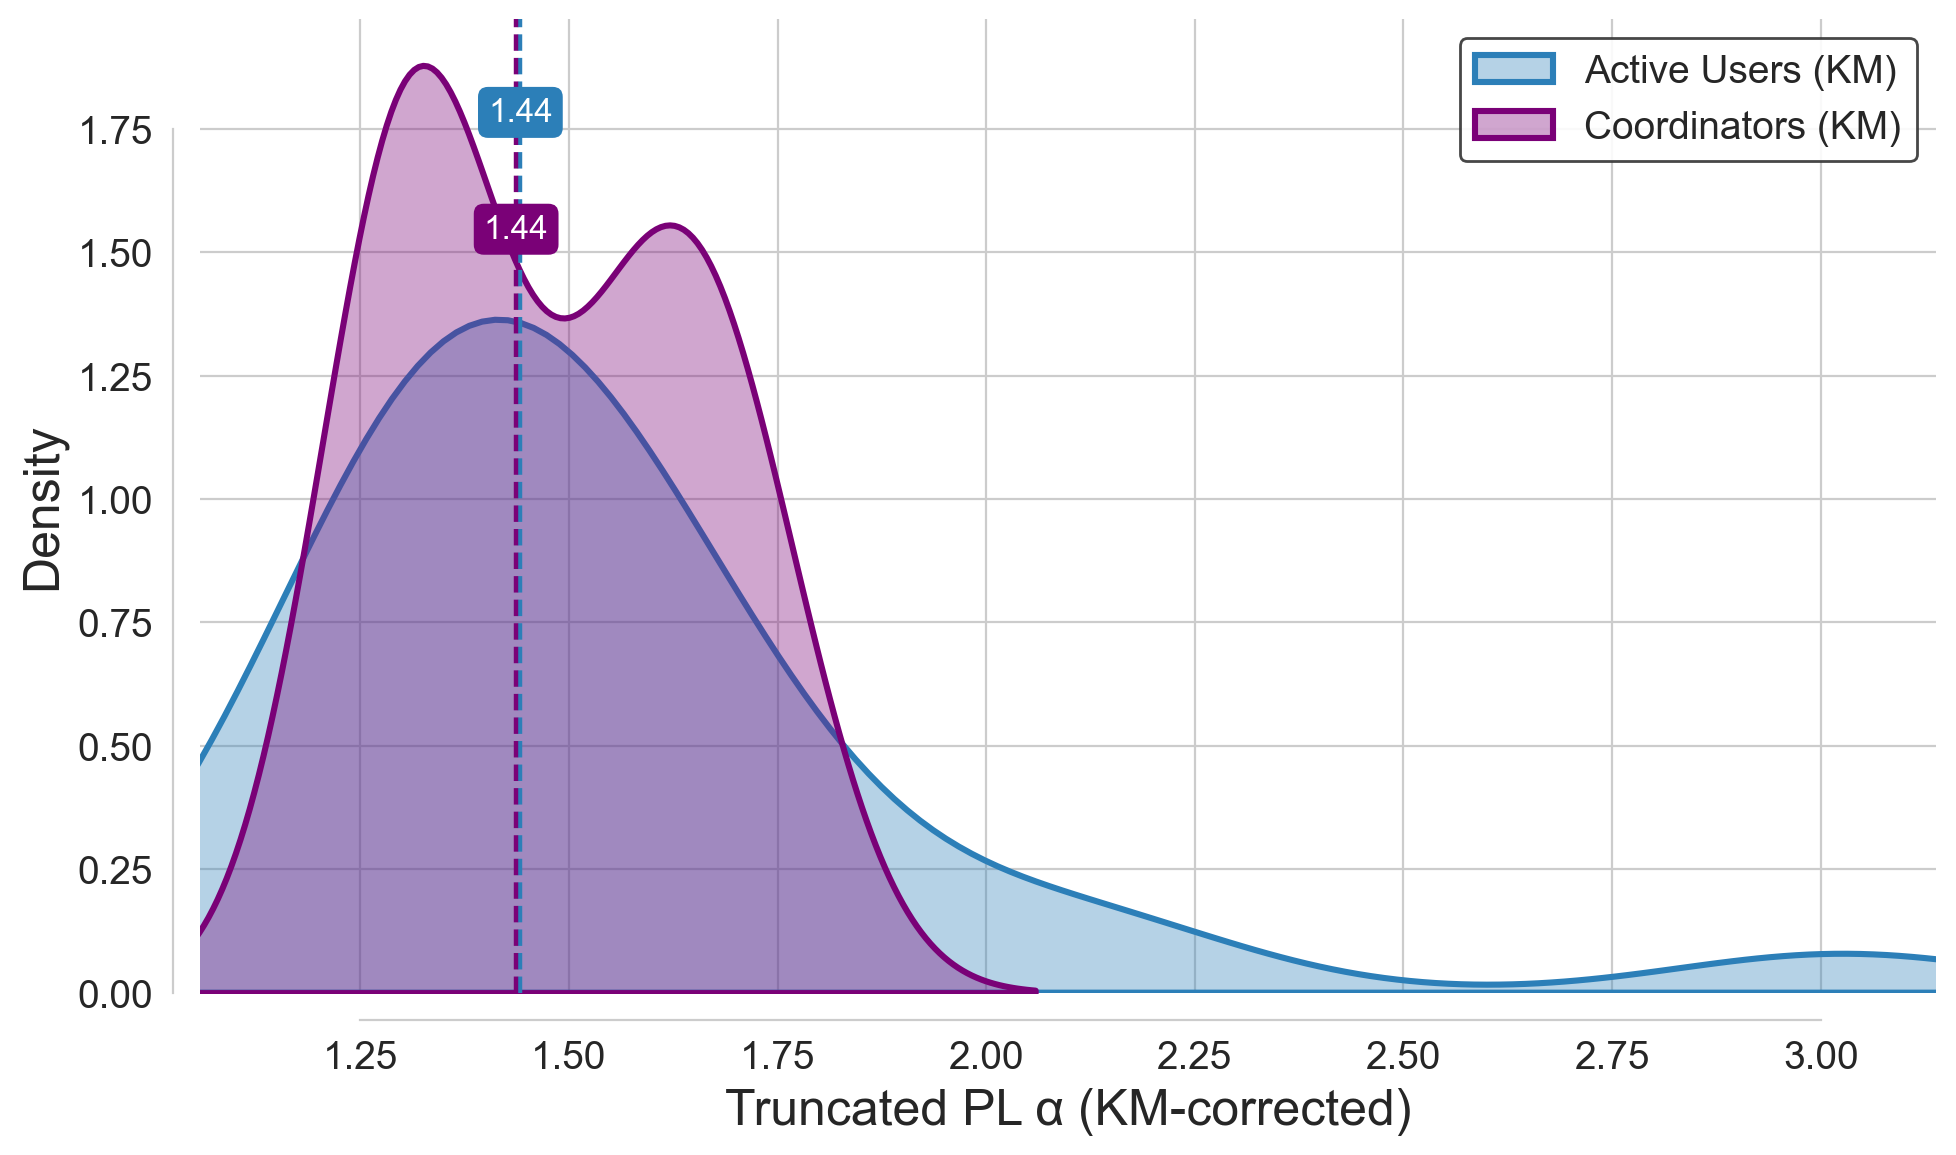

Saved: ./alpha_tpl_km_users_poster.svg


In [59]:
import os

def save_km_tpl_fig(out_dir='.', svg_name='alpha_tpl_km_users_poster.svg', dpi=600):
    os.makedirs(out_dir, exist_ok=True)
    blue   = '#2c7fb8'
    purple = '#7a0177'
    au    = np.asarray(alphas_au_tpl_km)
    coord = np.asarray(alphas_coord_tpl_km)

    fig, ax = plt.subplots(figsize=(10, 6), dpi=200)
    valid = np.concatenate([au[~np.isnan(au)], coord[~np.isnan(coord)]])
    if valid.size > 0:
        xlo, xhi = valid.min(), valid.max()
        pad = max(0.06 * (xhi - xlo), 0.1)
        ax.set_xlim(xlo - pad, xhi + pad)

    if au.size > 1:
        sns.kdeplot(au, ax=ax, color=blue, fill=True, alpha=0.35, linewidth=2.2,
                    label='Active Users (KM)', bw_method='scott')
    if coord.size > 1:
        sns.kdeplot(coord, ax=ax, color=purple, fill=True, alpha=0.35, linewidth=2.2,
                    label='Coordinators (KM)', bw_method='scott')

    ymax = ax.get_ylim()[1]
    for vals, color, yf in [(au, blue, 0.92), (coord, purple, 0.80)]:
        if vals.size:
            med = np.nanmedian(vals)
            ax.axvline(med, color=color, linestyle='--', linewidth=1.6)
            ax.text(med, ymax * yf, f'{med:.2f}', color='white', fontsize=12,
                    ha='center', va='top',
                    bbox=dict(facecolor=color, edgecolor='none', boxstyle='round,pad=0.3'))

    ax.set_xlabel('Truncated PL α (KM-corrected)', fontsize=18)
    ax.set_ylabel('Density', fontsize=18)
    leg = ax.legend(frameon=True, facecolor='white', edgecolor='0.2',
                    framealpha=0.9, loc='upper right', fontsize=14)
    ax.tick_params(axis='both', labelsize=14)
    sns.despine(trim=True, offset=10)
    fig.tight_layout()

    svg_path = os.path.join(out_dir, svg_name)
    fig.savefig(svg_path, dpi=dpi, bbox_inches='tight')
    plt.show()
    print(f'Saved: {svg_path}')

save_km_tpl_fig()


## PL vs TPL model comparison on KM-corrected survival curves

In [60]:
def compare_pl_tpl_km(users, messages_df, cutoff):
    """
    For each user, fits both PL and TPL to the KM-corrected survival curve
    and compares them with AIC (k=1 vs k=2 parameters).

    ΔAIC = AIC_TPL - AIC_PL
      < -2  → TPL clearly better
      > +2  → PL clearly better
      else  → no clear preference
    """
    results = []
    for user in users:
        user_msgs = messages_df[messages_df['sender_id'] == user]
        user_dates = pd.to_datetime(user_msgs['date'], errors='coerce').dropna().sort_values()
        if len(user_dates) < 10:
            continue
        waiting = user_dates.diff().dt.total_seconds().dropna()
        waiting = waiting[(waiting > 0) & np.isfinite(waiting)].values
        if len(waiting) < 10:
            continue

        tau_fc = max((cutoff - user_dates.iloc[-1]).total_seconds(), 0.0)
        km_dur = np.concatenate([waiting, waiting, [tau_fc]])
        km_obs = np.concatenate([np.ones(len(waiting)), np.ones(len(waiting)), [0]])
        kmf = KaplanMeierFitter()
        kmf.fit(km_dur, event_observed=km_obs.astype(bool))

        fit    = powerlaw.Fit(waiting, discrete=True, verbose=False)
        xmin   = float(getattr(fit.power_law, 'xmin', np.nan))
        a0_pl  = float(getattr(fit.power_law, 'alpha', 2.0))
        a0_tpl = float(getattr(fit.truncated_power_law, 'alpha', 2.0))

        km_t = kmf.survival_function_.index.values
        km_s = kmf.survival_function_['KM_estimate'].values
        mask  = (km_t >= xmin) & (km_s > 0) & (km_t > 0)
        if not np.isfinite(xmin) or mask.sum() < 5:
            continue

        km_t_tail = km_t[mask]
        s_at_xmin = float(np.interp(xmin, km_t, km_s))
        if s_at_xmin <= 0:
            continue
        km_s_norm = km_s[mask] / s_at_xmin   # normalize so S(xmin) = 1
        n = len(km_t_tail)

        def pl_surv(t, alpha):
            return (t / xmin) ** (-(alpha - 1))

        def tpl_surv(t, alpha, lam):
            return (t / xmin) ** (-(alpha - 1)) * np.exp(-(t - xmin) * lam)

        try:
            popt_pl, _ = curve_fit(pl_surv, km_t_tail, km_s_norm,
                                   p0=[max(a0_pl, 1.01)],
                                   bounds=([1.001], [20.0]), maxfev=10000)
            rss_pl  = float(np.sum((km_s_norm - pl_surv(km_t_tail, *popt_pl)) ** 2))
            aic_pl  = n * np.log(rss_pl / n) + 2 * 1
        except Exception:
            continue

        try:
            popt_tpl, _ = curve_fit(tpl_surv, km_t_tail, km_s_norm,
                                    p0=[max(a0_tpl, 1.01), 1.0 / waiting.max()],
                                    bounds=([1.001, 0.0], [20.0, np.inf]), maxfev=10000)
            rss_tpl = float(np.sum((km_s_norm - tpl_surv(km_t_tail, *popt_tpl)) ** 2))
            aic_tpl = n * np.log(rss_tpl / n) + 2 * 2
        except Exception:
            continue

        delta_aic = aic_tpl - aic_pl   # negative → TPL better
        results.append({
            'user_id':      user,
            'alpha_pl':     float(popt_pl[0]),
            'alpha_tpl':    float(popt_tpl[0]),
            'lambda_tpl':   float(popt_tpl[1]),
            'rss_pl':       rss_pl,
            'rss_tpl':      rss_tpl,
            'delta_aic':    delta_aic,
            'better_model': 'TPL' if delta_aic < -2 else ('PL' if delta_aic > 2 else 'tie'),
        })
    return pd.DataFrame(results)


cutoff_date = df['date'].max()

df_au_cmp    = compare_pl_tpl_km(active_users,              active_users_messages,  cutoff_date)
df_coord_cmp = compare_pl_tpl_km(coordinators_id.values(),  coordinators_messages,  cutoff_date)

for label, res in [('Active Users', df_au_cmp), ('Coordinators', df_coord_cmp)]:
    print(f"\n{'='*50}")
    print(f"{label}  (n={len(res)})")
    print(f"{'='*50}")
    if res.empty:
        print("  No results.")
        continue
    counts = res['better_model'].value_counts()
    for m in ['TPL', 'PL', 'tie']:
        print(f"  {m}: {counts.get(m, 0)}/{len(res)} users  "
              f"({100 * counts.get(m, 0) / len(res):.0f}%)")
    print(f"\n  Mean ΔAIC (TPL−PL): {res['delta_aic'].mean():.2f}  "
          f"(negative = TPL better)")
    print(f"  Median ΔAIC:        {res['delta_aic'].median():.2f}")


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges


Active Users  (n=25)
  TPL: 13/25 users  (52%)
  PL: 3/25 users  (12%)
  tie: 9/25 users  (36%)

  Mean ΔAIC (TPL−PL): -21.91  (negative = TPL better)
  Median ΔAIC:        -2.58

Coordinators  (n=10)
  TPL: 5/10 users  (50%)
  PL: 2/10 users  (20%)
  tie: 3/10 users  (30%)

  Mean ΔAIC (TPL−PL): -20.56  (negative = TPL better)
  Median ΔAIC:        -2.26


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


## Groups of 11 active users — bootstrap comparison to coordinators

Coordinator group size: 10  |  Active users pool: 25

Bootstrap permutation test  (group size=10,  iterations=5000)
  α  — coordinators median = 1.437,  null mean = 1.448 ± 0.071,  p = 0.8624
  λ  — coordinators median = 6.55e-07,  null mean = 1.17e-06 ± 9.60e-07,  p = 0.5290


/var/folders/t0/sjtcv6y97xnczv424tb3c5yc0000gn/T/ipykernel_17331/2332105864.py:68: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.tight_layout()


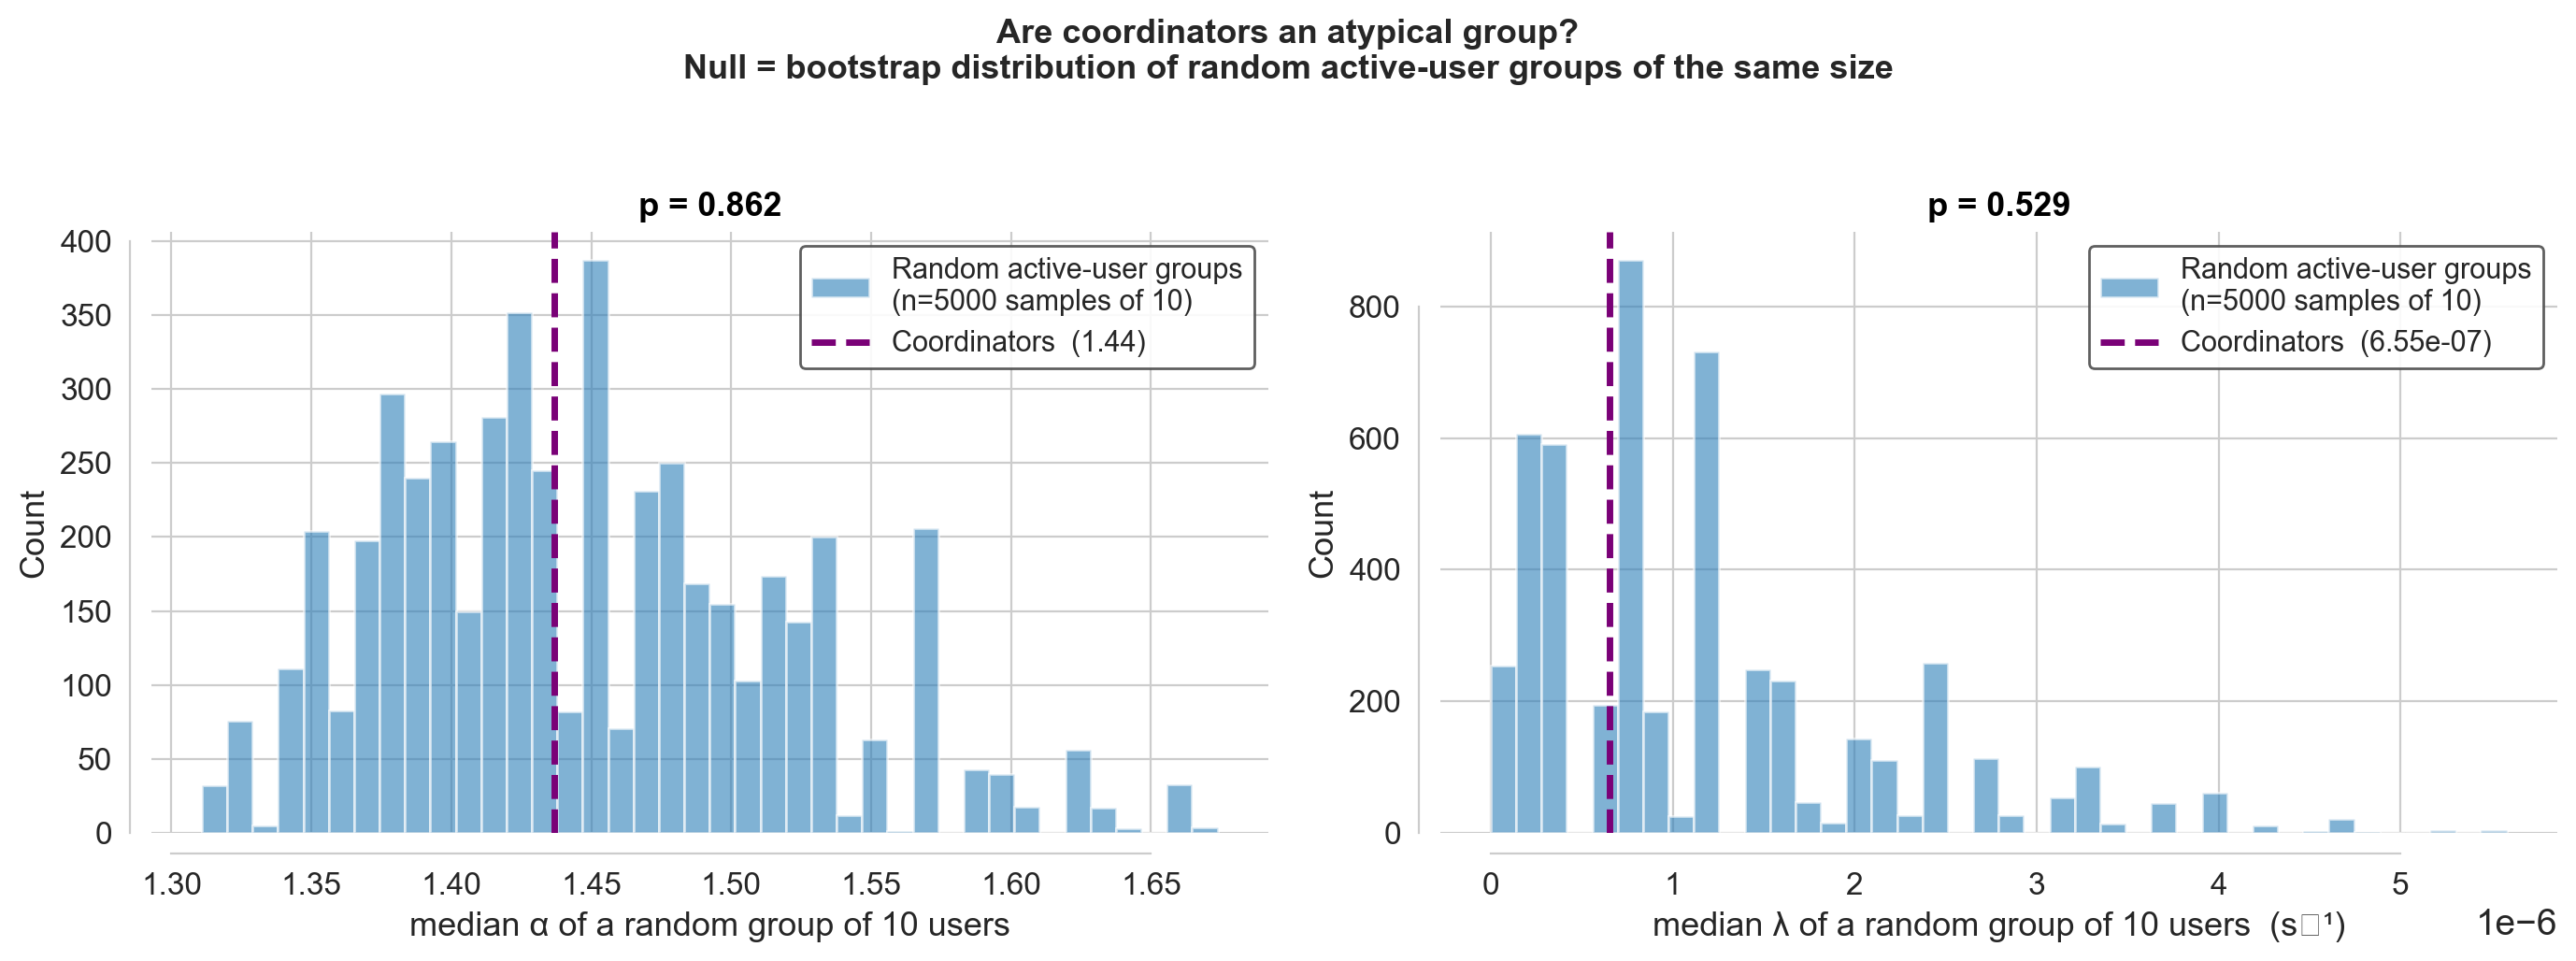

In [63]:
import numpy as np

# ── Per-user TPL params from the KM-corrected comparison DataFrames ───────────
alpha_au    = df_au_cmp['alpha_tpl'].dropna().values
lam_au      = df_au_cmp['lambda_tpl'].dropna().values
alpha_coord = df_coord_cmp['alpha_tpl'].dropna().values
lam_coord   = df_coord_cmp['lambda_tpl'].dropna().values

# Group size = number of coordinators with a valid TPL fit
group_size  = len(alpha_coord)
n_bootstrap = 5000
rng = np.random.default_rng(42)

print(f"Coordinator group size: {group_size}  |  Active users pool: {len(alpha_au)}")

# ── Bootstrap null: sample many random groups of <group_size> active users ───
# For each sample, compute the group median α and λ (same summary statistic
# we observe for coordinators). This builds the null distribution of what a
# typical group of the same size looks like.
boot_alpha = np.array([np.median(alpha_au[rng.choice(len(alpha_au), size=group_size, replace=False)])
                        for _ in range(n_bootstrap)])
boot_lam   = np.array([np.median(lam_au[rng.choice(len(lam_au),   size=group_size, replace=False)])
                        for _ in range(n_bootstrap)])

# ── Coordinator observed statistics ──────────────────────────────────────────
coord_alpha_med = np.median(alpha_coord)
coord_lam_med   = np.median(lam_coord)

# Two-sided p-value: fraction of bootstrap samples at least as extreme as coordinators
p_alpha = np.mean(np.abs(boot_alpha - boot_alpha.mean()) >= np.abs(coord_alpha_med - boot_alpha.mean()))
p_lam   = np.mean(np.abs(boot_lam   - boot_lam.mean())   >= np.abs(coord_lam_med   - boot_lam.mean()))

print(f"\nBootstrap permutation test  (group size={group_size},  iterations={n_bootstrap})")
print(f"  α  — coordinators median = {coord_alpha_med:.3f},  "
      f"null mean = {boot_alpha.mean():.3f} ± {boot_alpha.std():.3f},  p = {p_alpha:.4f}")
print(f"  λ  — coordinators median = {coord_lam_med:.2e},  "
      f"null mean = {boot_lam.mean():.2e} ± {boot_lam.std():.2e},  p = {p_lam:.4f}")

# ── Plot: null distribution of group medians + coordinator value ──────────────
blue   = '#2c7fb8'
purple = '#7a0177'

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=200)

panels = [
    (boot_alpha, coord_alpha_med, f'median α of a random group of {group_size} users', p_alpha),
    (boot_lam,   coord_lam_med,   f'median λ of a random group of {group_size} users  (s⁻¹)', p_lam),
]

for ax, (boot_vals, coord_val, xlabel, pval) in zip(axes, panels):
    ax.hist(boot_vals, bins=40, color=blue, alpha=0.6,
            label=f'Random active-user groups\n(n={n_bootstrap} samples of {group_size})')
    ax.axvline(coord_val, color=purple, linewidth=2.5, linestyle='--',
               label=f'Coordinators  ({coord_val:.3g})')

    sig_str = f'p = {pval:.3f}' if pval >= 0.001 else f'p = {pval:.2e}'
    ax.set_title(sig_str, fontsize=13, weight='bold',
                 color='crimson' if pval < 0.05 else 'black')
    ax.set_xlabel(xlabel, fontsize=13)
    ax.set_ylabel('Count', fontsize=13)
    ax.legend(frameon=True, facecolor='white', edgecolor='0.3', framealpha=0.9, fontsize=11)
    ax.tick_params(labelsize=12)
    sns.despine(ax=ax, trim=True, offset=8)

fig.suptitle('Are coordinators an atypical group?\n'
             'Null = bootstrap distribution of random active-user groups of the same size',
             fontsize=13, weight='bold', y=1.03)
fig.tight_layout()
plt.show()

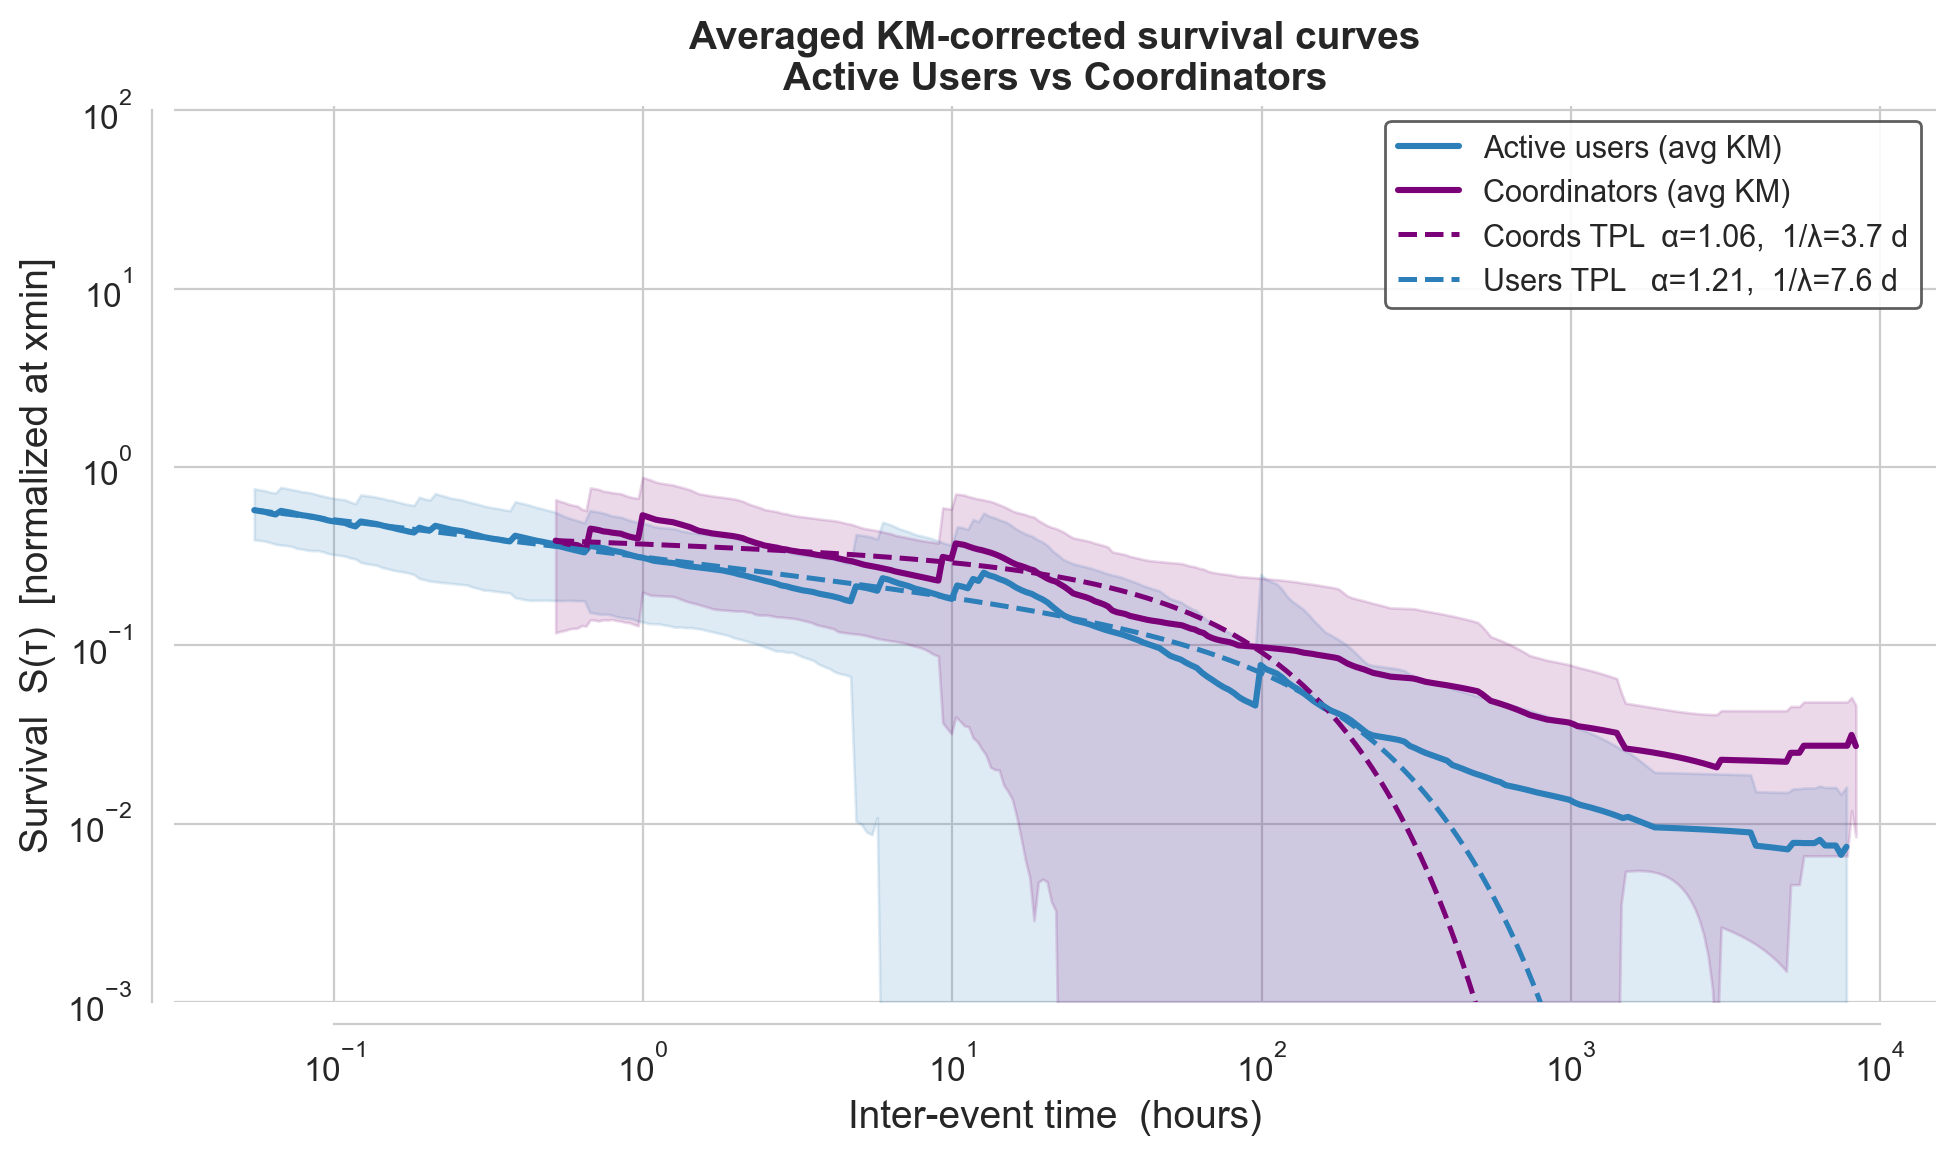


Group-level TPL fit on averaged survival curve:
  Active Users :  α=1.207,   λ=1.52e-06 s⁻¹   →  1/λ = 7.6 days
  Coordinators :  α=1.060,   λ=3.14e-06 s⁻¹   →  1/λ = 3.7 days


In [65]:
def avg_km_survival(users, messages_df, cutoff, t_grid=None):
    curves = []
    xmins  = []
    for user in users:
        user_msgs  = messages_df[messages_df['sender_id'] == user]
        user_dates = pd.to_datetime(user_msgs['date'], errors='coerce').dropna().sort_values()
        if len(user_dates) < 10:
            continue
        waiting = user_dates.diff().dt.total_seconds().dropna()
        waiting = waiting[(waiting > 0) & np.isfinite(waiting)].values
        if len(waiting) < 10:
            continue

        tau_fc = max((cutoff - user_dates.iloc[-1]).total_seconds(), 0.0)
        km_dur = np.concatenate([waiting, waiting, [tau_fc]])
        km_obs = np.concatenate([np.ones(len(waiting)), np.ones(len(waiting)), [0]])
        kmf = KaplanMeierFitter()
        kmf.fit(km_dur, event_observed=km_obs.astype(bool))

        fit  = powerlaw.Fit(waiting, discrete=True, verbose=False)
        xmin = float(getattr(fit.power_law, 'xmin', np.nan))
        if not np.isfinite(xmin) or xmin <= 0:
            continue

        km_t = kmf.survival_function_.index.values
        km_s = kmf.survival_function_['KM_estimate'].values
        s_at_xmin = float(np.interp(xmin, km_t, km_s))
        if s_at_xmin <= 0:
            continue

        # Keep only tail (t >= xmin), normalized so S(xmin) = 1
        mask = km_t >= xmin
        curves.append((km_t[mask], km_s[mask] / s_at_xmin))
        xmins.append(xmin)

    if not curves:
        return None, None, None, None

    xmin_common = np.median(xmins)
    # Use median last-event time to avoid one long-lived user stretching the grid
    t_max = np.percentile([c[0][-1] for c in curves], 50)
    if t_grid is None:
        t_grid = np.geomspace(xmin_common, t_max, 300)

    # Interpolate; beyond a user's last event use NaN (don't pull mean down to 0)
    interp_mat = np.full((len(curves), len(t_grid)), np.nan)
    for i, (km_t, km_s_norm) in enumerate(curves):
        in_range = (t_grid >= km_t[0]) & (t_grid <= km_t[-1])
        interp_mat[i, in_range] = np.interp(t_grid[in_range], km_t, km_s_norm)

    # Only average over users that still have data at each point
    with np.errstate(all='ignore'):
        s_mean = np.nanmean(interp_mat, axis=0)
        s_std  = np.nanstd(interp_mat, axis=0)

    # Trim to where at least half the users contribute
    n_valid = np.sum(~np.isnan(interp_mat), axis=0)
    keep = n_valid >= max(1, len(curves) // 2)
    return t_grid[keep], s_mean[keep], s_std[keep], xmin_common


# ── Compute averaged survival curves ─────────────────────────────────────────
t_coord, s_coord, std_coord, xmin_coord = avg_km_survival(
    coordinators_id.values(), coordinators_messages, cutoff_date)

t_au, s_au, std_au, xmin_au = avg_km_survival(
    active_users, active_users_messages, cutoff_date)

# ── Fit TPL to each averaged curve (within the fitted range only) ─────────────
def fit_tpl_to_avg(t_grid, s_mean, xmin_common):
    mask = (t_grid >= xmin_common) & (s_mean > 0)
    if mask.sum() < 5:
        return None, None
    t_tail = t_grid[mask]
    s_norm = s_mean[mask] / float(np.interp(xmin_common, t_grid, s_mean))

    def tpl_surv(t, alpha, lam):
        return (t / xmin_common) ** (-(alpha - 1)) * np.exp(-(t - xmin_common) * lam)
    try:
        popt, _ = curve_fit(tpl_surv, t_tail, s_norm,
                            p0=[1.5, 1e-6], bounds=([1.001, 0.0], [20.0, np.inf]),
                            maxfev=10000)
        return popt, t_tail
    except Exception:
        return None, None

popt_coord, t_tail_coord = fit_tpl_to_avg(t_coord, s_coord, xmin_coord)
popt_au,    t_tail_au    = fit_tpl_to_avg(t_au,    s_au,    xmin_au)

# ── Plot ──────────────────────────────────────────────────────────────────────
blue   = '#2c7fb8'
purple = '#7a0177'

fig, ax = plt.subplots(figsize=(10, 6), dpi=200)

ax.plot(t_au / 3600, s_au, color=blue, linewidth=2.2, label='Active users (avg KM)')
ax.fill_between(t_au / 3600,
                np.clip(s_au - std_au, 1e-4, None), s_au + std_au,
                color=blue, alpha=0.15)

ax.plot(t_coord / 3600, s_coord, color=purple, linewidth=2.2, label='Coordinators (avg KM)')
ax.fill_between(t_coord / 3600,
                np.clip(s_coord - std_coord, 1e-4, None), s_coord + std_coord,
                color=purple, alpha=0.15)

# TPL fits — plotted only over the range they were fitted (no extrapolation)
if popt_coord is not None:
    a, l = popt_coord
    char_c = 1 / (l * 86400)
    s_at_xmin_c = float(np.interp(xmin_coord, t_coord, s_coord))
    s_fit = (t_tail_coord / xmin_coord)**(-(a-1)) * np.exp(-(t_tail_coord - xmin_coord)*l) * s_at_xmin_c
    ax.plot(t_tail_coord / 3600, s_fit, color=purple, linewidth=1.8,
            linestyle='--', label=f'Coords TPL  α={a:.2f},  1/λ={char_c:.1f} d')

if popt_au is not None:
    a, l = popt_au
    char_a = 1 / (l * 86400)
    s_at_xmin_a = float(np.interp(xmin_au, t_au, s_au))
    s_fit = (t_tail_au / xmin_au)**(-(a-1)) * np.exp(-(t_tail_au - xmin_au)*l) * s_at_xmin_a
    ax.plot(t_tail_au / 3600, s_fit, color=blue, linewidth=1.8,
            linestyle='--', label=f'Users TPL   α={a:.2f},  1/λ={char_a:.1f} d')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(bottom=1e-3)
ax.set_xlabel('Inter-event time  (hours)', fontsize=14)
ax.set_ylabel('Survival  S(τ)  [normalized at xmin]', fontsize=14)
ax.set_title('Averaged KM-corrected survival curves\nActive Users vs Coordinators', fontsize=14, weight='bold')
ax.legend(frameon=True, facecolor='white', edgecolor='0.3', framealpha=0.9, fontsize=11)
ax.tick_params(labelsize=12)
sns.despine(ax=ax, trim=True, offset=8)
fig.tight_layout()
plt.show()

if popt_coord is not None and popt_au is not None:
    char_c = 1 / (popt_coord[1] * 86400)
    char_a = 1 / (popt_au[1]    * 86400)
    print(f"\nGroup-level TPL fit on averaged survival curve:")
    print(f"  Active Users :  α={popt_au[0]:.3f},   λ={popt_au[1]:.2e} s⁻¹   →  1/λ = {char_a:.1f} days")
    print(f"  Coordinators :  α={popt_coord[0]:.3f},   λ={popt_coord[1]:.2e} s⁻¹   →  1/λ = {char_c:.1f} days")

Running 300 bootstrap samples of 10 active users ...
  50/300 done  (valid fits: 50)
  100/300 done  (valid fits: 100)
  150/300 done  (valid fits: 150)
  200/300 done  (valid fits: 200)
  250/300 done  (valid fits: 250)
  300/300 done  (valid fits: 300)
Bootstrap TPL-curve test  (group size=10, valid=300)
  alpha  coords=1.060,  null=1.195+-0.064,  p=0.0433
  lambda coords=3.14e-06 s-1  -> 1/lambda=3.7 d,  p=0.5633


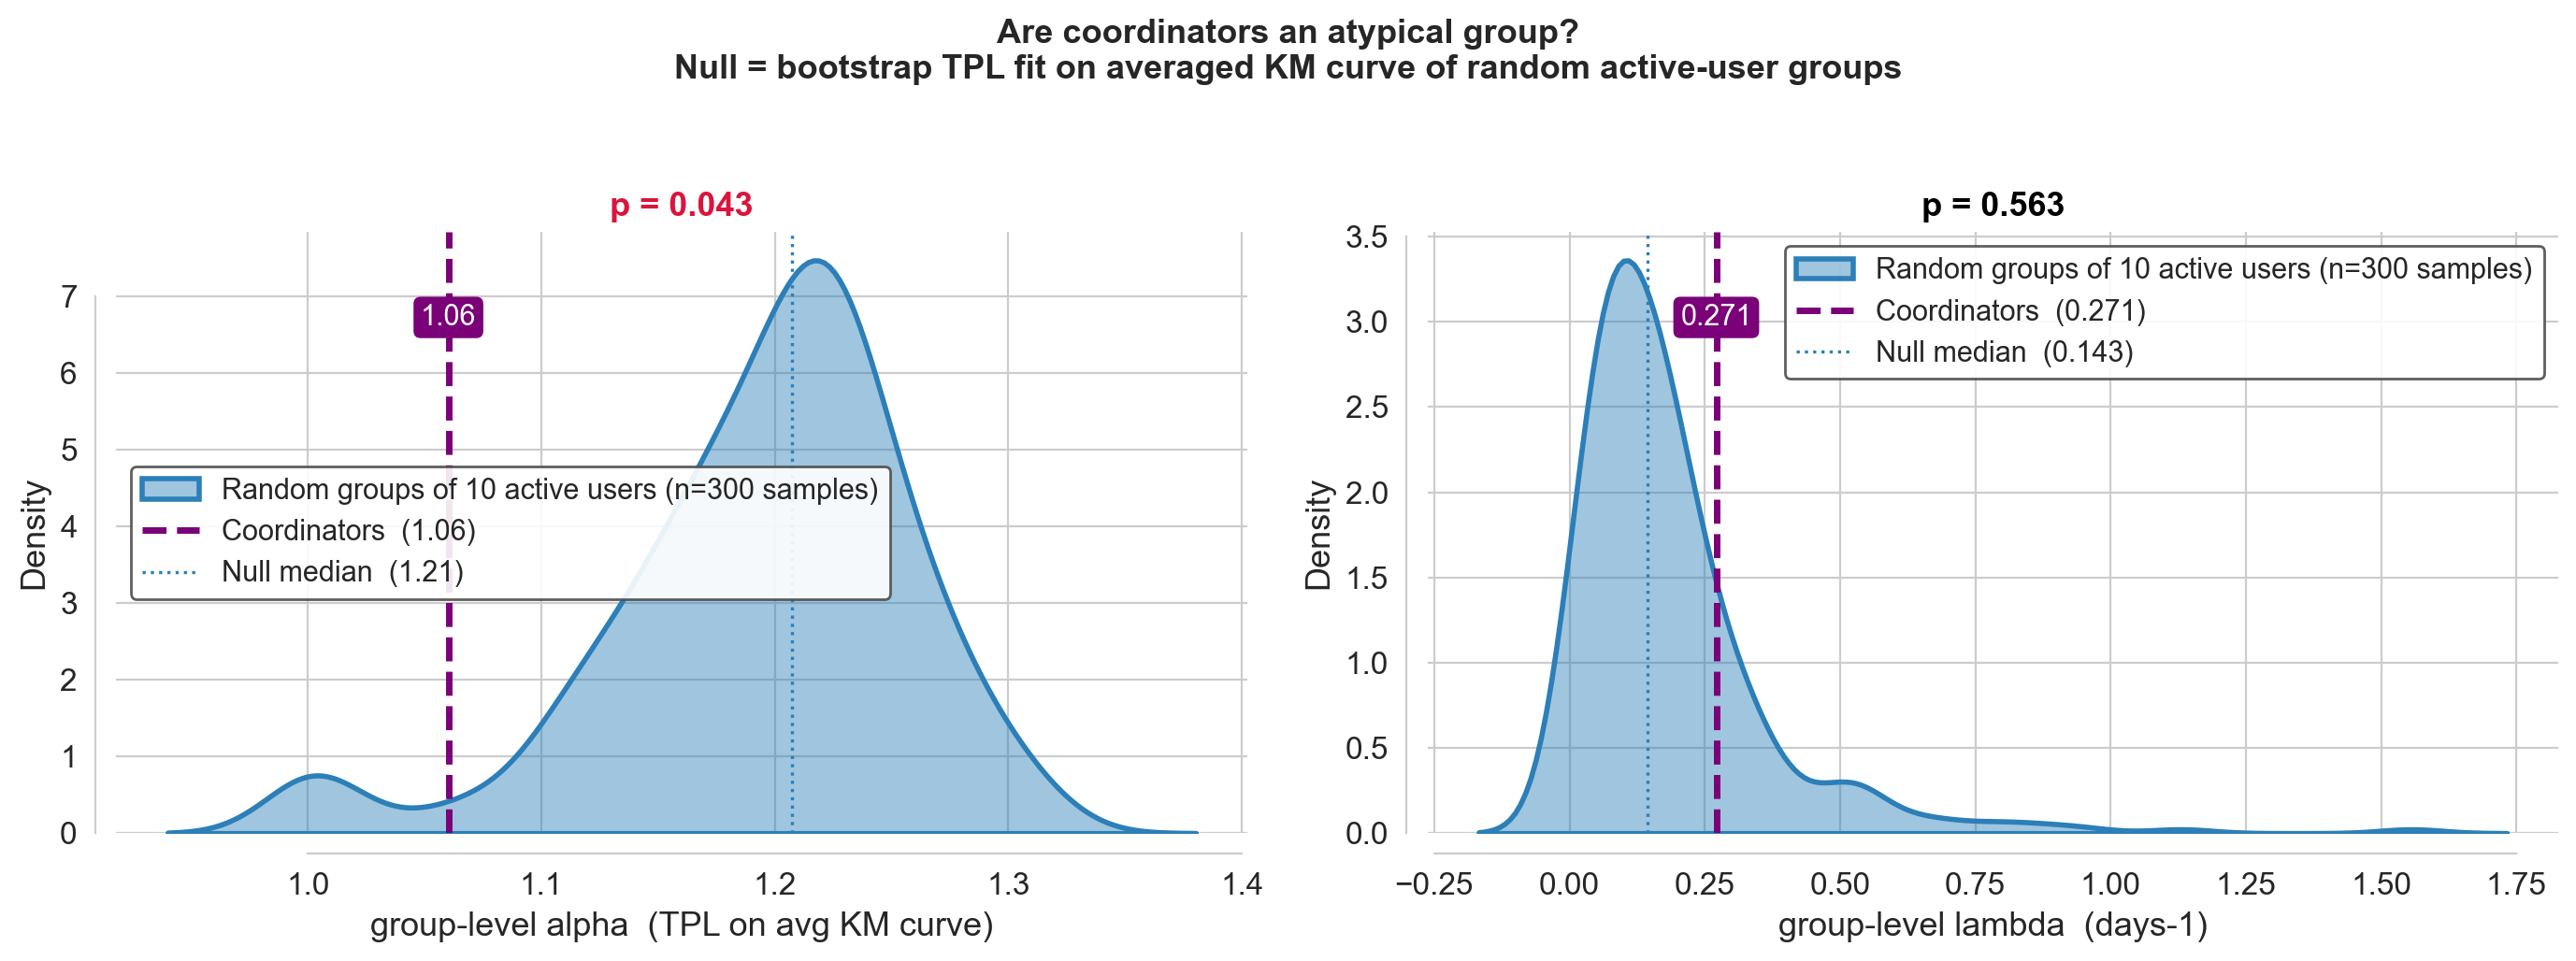

In [66]:
# Bootstrap: for each random group of <group_size> active users, compute the
# averaged KM survival curve and fit a TPL to it — same procedure as for
# coordinators above. Builds a null distribution of group-level (alpha, lambda).

group_size  = len(alpha_coord)   # match coordinator group size
n_bootstrap = 300                # each iteration = group_size KM fits + curve_fit
rng_b = np.random.default_rng(42)
au_list = list(active_users)

boot_alpha_curve = []
boot_lam_curve   = []

print(f"Running {n_bootstrap} bootstrap samples of {group_size} active users ...")
for i in range(n_bootstrap):
    idx_b   = rng_b.choice(len(au_list), size=group_size, replace=False)
    sampled = [au_list[j] for j in idx_b]

    t_b, s_b, _, xmin_b = avg_km_survival(sampled, active_users_messages, cutoff_date)
    if t_b is None or len(t_b) < 5:
        continue

    popt_b, _ = fit_tpl_to_avg(t_b, s_b, xmin_b)
    if popt_b is None:
        continue

    boot_alpha_curve.append(float(popt_b[0]))
    boot_lam_curve.append(float(popt_b[1]))

    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{n_bootstrap} done  (valid fits: {len(boot_alpha_curve)})")

boot_alpha_curve = np.array(boot_alpha_curve)
boot_lam_curve   = np.array(boot_lam_curve)

# Coordinator group-level TPL (from averaged curve in previous cell)
coord_alpha_curve = float(popt_coord[0])
coord_lam_curve   = float(popt_coord[1])

# Two-sided p-values
p_a = np.mean(np.abs(boot_alpha_curve - boot_alpha_curve.mean()) >=
              np.abs(coord_alpha_curve - boot_alpha_curve.mean()))
p_l = np.mean(np.abs(boot_lam_curve   - boot_lam_curve.mean()) >=
              np.abs(coord_lam_curve   - boot_lam_curve.mean()))

print(f"Bootstrap TPL-curve test  (group size={group_size}, valid={len(boot_alpha_curve)})")
print(f"  alpha  coords={coord_alpha_curve:.3f},  null={boot_alpha_curve.mean():.3f}+-{boot_alpha_curve.std():.3f},  p={p_a:.4f}")
print(f"  lambda coords={coord_lam_curve:.2e} s-1  -> 1/lambda={1/(coord_lam_curve*86400):.1f} d,  p={p_l:.4f}")

# Plot
blue   = '#2c7fb8'
purple = '#7a0177'

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=200)

panels = [
    (boot_alpha_curve, coord_alpha_curve,
     f'group-level alpha  (TPL on avg KM curve)', p_a),
    (boot_lam_curve * 86400, coord_lam_curve * 86400,
     'group-level lambda  (days-1)', p_l),
]

for ax, (boot_vals, coord_val, xlabel, pval) in zip(axes, panels):
    sns.kdeplot(boot_vals, ax=ax, color=blue, fill=True, alpha=0.45,
                linewidth=2.0, bw_method='scott',
                label=f'Random groups of {group_size} active users (n={len(boot_vals)} samples)')

    ax.axvline(coord_val, color=purple, linewidth=2.5, linestyle='--',
               label=f'Coordinators  ({coord_val:.3g})')

    med_null = np.median(boot_vals)
    ax.axvline(med_null, color=blue, linewidth=1.2, linestyle=':',
               label=f'Null median  ({med_null:.3g})')

    ymax = ax.get_ylim()[1]
    ax.text(coord_val, ymax * 0.88, f'{coord_val:.3g}', color='white', fontsize=11,
            ha='center', va='top',
            bbox=dict(facecolor=purple, edgecolor='none', boxstyle='round,pad=0.25'))

    sig_str = f'p = {pval:.3f}' if pval >= 0.001 else f'p = {pval:.2e}'
    ax.set_title(sig_str, fontsize=13, weight='bold',
                 color='crimson' if pval < 0.05 else 'black')
    ax.set_xlabel(xlabel, fontsize=13)
    ax.set_ylabel('Density', fontsize=13)
    ax.legend(frameon=True, facecolor='white', edgecolor='0.3', framealpha=0.9, fontsize=11)
    ax.tick_params(labelsize=12)
    sns.despine(ax=ax, trim=True, offset=8)

fig.suptitle('Are coordinators an atypical group?\nNull = bootstrap TPL fit on averaged KM curve of random active-user groups',
             fontsize=13, weight='bold', y=1.03)
fig.tight_layout()
plt.show()


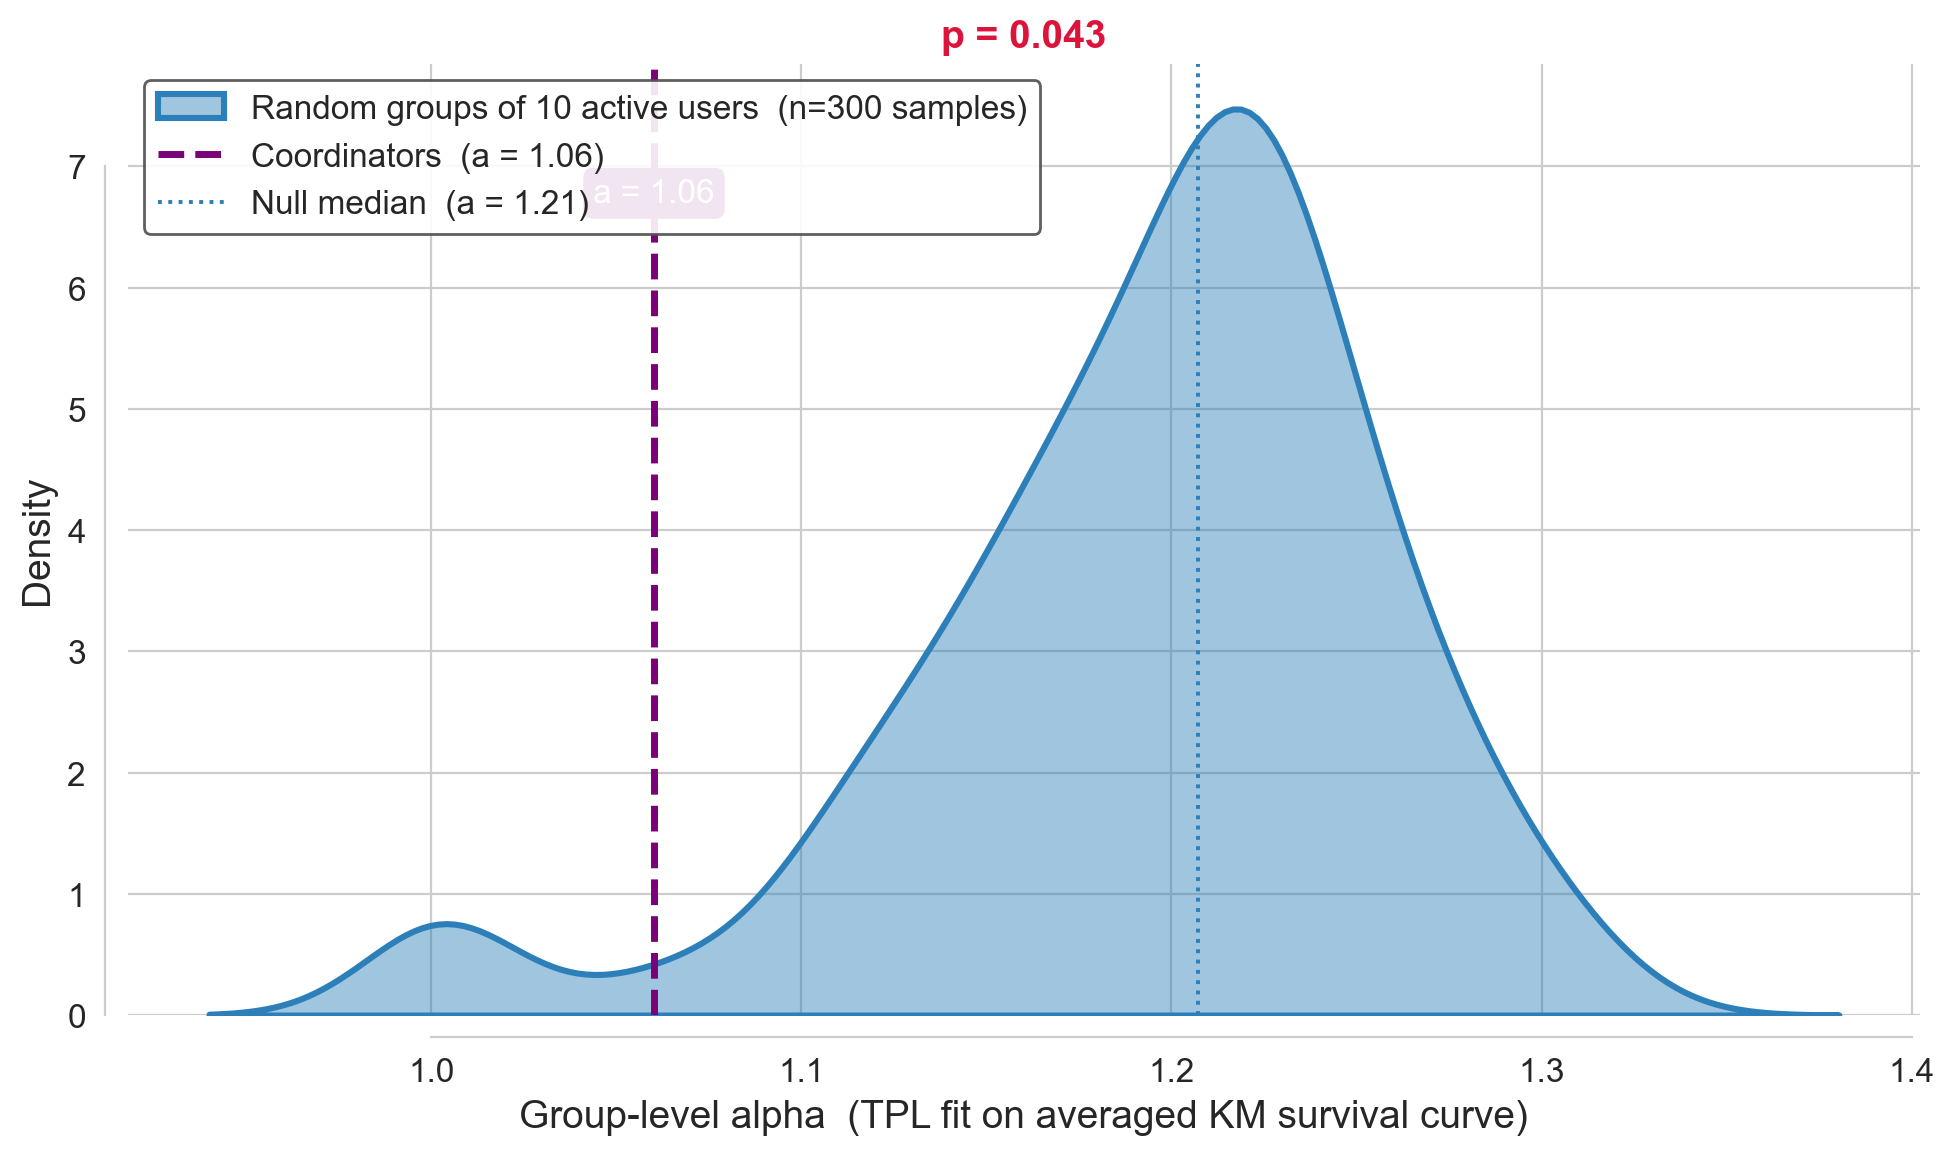

In [67]:
blue   = "#2c7fb8"
purple = "#7a0177"

fig, ax = plt.subplots(figsize=(10, 6), dpi=200)

sns.kdeplot(boot_alpha_curve, ax=ax, color=blue, fill=True, alpha=0.45,
            linewidth=2.2, bw_method="scott",
            label=f"Random groups of {group_size} active users  (n={len(boot_alpha_curve)} samples)")

ax.axvline(coord_alpha_curve, color=purple, linewidth=2.5, linestyle="--",
           label=f"Coordinators  (a = {coord_alpha_curve:.2f})")

med_null = np.median(boot_alpha_curve)
ax.axvline(med_null, color=blue, linewidth=1.4, linestyle=":",
           label=f"Null median  (a = {med_null:.2f})")

ymax = ax.get_ylim()[1]
ax.text(coord_alpha_curve, ymax * 0.88, f"a = {coord_alpha_curve:.2f}",
        color="white", fontsize=12, ha="center", va="top",
        bbox=dict(facecolor=purple, edgecolor="none", boxstyle="round,pad=0.3"))

sig_str = f"p = {p_a:.3f}" if p_a >= 0.001 else f"p = {p_a:.2e}"
ax.set_title(sig_str, fontsize=14, weight="bold",
             color="crimson" if p_a < 0.05 else "black")
ax.set_xlabel("Group-level alpha  (TPL fit on averaged KM survival curve)", fontsize=14)
ax.set_ylabel("Density", fontsize=14)
ax.legend(frameon=True, facecolor="white", edgecolor="0.3", framealpha=0.9, fontsize=12)
ax.tick_params(labelsize=12)
sns.despine(ax=ax, trim=True, offset=8)
fig.tight_layout()
plt.show()
